# MeteoScreening `SWC_FF1_0.5_1` (2020-2025) from database (influxdb)

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `SWC_FF1_0.5_1` &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025  
**Cross-check**: the other depths of the same soil profile (`0.05`, `0.1`, `0.2`, `0.3` m) and the screened precipitation product — see *Cross-check* below  
**Derived from**: the 5 cm screening notebook `SWC_FF1_0.05_1_2020-2025.ipynb` (itself from diive template `DatabaseInfluxStepwiseMeteoScreening.ipynb`, version `9`, 15 Jul 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw soil water content from the InfluxDB database, quality-screen and correct it on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses `StepwiseMeteoScreeningDb` from [diive](https://github.com/holukas/diive) (`diive/preprocessing/qaqc/meteoscreening.py`); download and upload use diive's in-house InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`).

**Flow:** download (`InfluxIO`) → cross-check against the rest of the soil profile → screen on high-res data (`diive`) → resample to 30MIN → validate against the profile → upload.

**Outlier detection is stepwise:** run a test, inspect its preview plot, then commit it with `mscr.addflag()`. Re-run with different parameters as often as you like before committing. Run only the tests a variable actually needs. At the end all committed flags are aggregated into one overall quality flag `QCF`.

**This notebook is one of the depth copies.** The pattern is the shallowest sensor's notebook, `SWC_FF1_0.05_1_2020-2025.ipynb`; this is its copy for the **deepest** probe (50 cm), with `DEPTH` changed and `REMOVE_DATES` **re-derived from this sensor's own evidence**. At 50 cm that evidence points to a **clean record**: `REMOVE_DATES` is empty and the two manual-removal cells skip themselves. See the closing notes *The record is clean* for the positive case and *Reading a deep sensor* for the two cross-check traps a 50 cm probe springs.

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). Note that diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here. From this repo the extra is the only route.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval). Getting the timestamp right is the one thing that must not go wrong, because the day/night split during screening — and the value written back to the DB — both depend on it.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). It is applied **identically** on download and on upload. Here is the full round-trip, all handled for you:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

So screening runs on correct local middle-of-period timestamps, and the resampled value lands on the correct UTC end-of-period stamp in the DB. **`TIMEZONE_OFFSET_TO_UTC_HOURS` must match the timezone the raw data was logged in** (e.g. `1` for CET winter time) and must be the same value everywhere. This notebook prints the timestamps right after download and right after the verification download so you can confirm they look correct.

Everything in the *Cross-check* section works on `TIMESTAMP_END` as downloaded. The precipitation product read there is stored on `TIMESTAMP_MID` and is shifted to `TIMESTAMP_END` before use.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening (not used for soil moisture — see *Outlier detection*).

**Variable to screen**
- `PROFILE`, `DEPTH`, `REPL`: the sensor's position tags. `FIELD` is assembled from them and is the InfluxDB `_field`. **This is the only place to change when screening another depth.**
- `MEASUREMENT`: exactly **one** measurement grouping the variables — `SWC` for soil water content.
- `COMPANION_DEPTHS`: the other depths of the same profile, used as the cross-check reference. They are *not* screened here.

**Time range to screen**
- `START`: first timestamp to screen — **is** included.
- `STOP`: upper bound — **is not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see the *Timestamp convention* section above. Must match how the raw data was logged (e.g. `1` for CET winter time).
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ`: the screened high-res data is resampled to this frequency.
- `RESAMPLING_AGG`: aggregation used when resampling. Soil water content is a **state**, so `'mean'` — never `'sum'`.

**Cross-check**
- `PREC_PRODUCT` / `PREC_COL`: the screened precipitation product, used to test whether the sensor still *responds* to rain. Produced by [`30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb`](../../30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb).
- `PROFILE_PRODUCT`: the raw FF1 profile (all five depths in one file), downloaded once by [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb) and read here for the companion depths instead of downloading them again in every depth's notebook. The screened variable is **not** read from it — that one still comes from the database download, which carries the tags screening needs.
- `FIELDBOOK`: the GIN fieldbook export, read directly here so that every candidate period is adjudicated against the site record in the notebook rather than by hand.

**Parameter help**
- `SHOW_PARAM_HELP`: set `True` to print the full docstring (all parameters) of each screening method right before it runs. Leave `False` for a clean, concise notebook.

In [1]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# --- Variable to screen ---
# Verified 21 Jul 2026 against measurement SWC of bucket ch-lae_raw: the FF1 profile
# holds five depths (0.05, 0.1, 0.2, 0.3, 0.5), all TEROS 12, all starting
# 2020-04-10. (The older M5 profile, SWC_M5_*, ends the same day and is a
# different, now-trashed sensor set - see the closing note. The FF3 profile
# starts only in 2026 and is out of scope here.)
PROFILE = 'FF1'  # horizontal position (soil profile)
DEPTH = '0.5'  # <-- the only setting to change between depth copies (this one: the deepest probe, 50 cm)
REPL = '1'  # replicate
FIELD = f'SWC_{PROFILE}_{DEPTH}_{REPL}'
FIELDS = [FIELD]  # StepwiseMeteoScreeningDb expects a list
MEASUREMENT = 'SWC'

# The rest of the profile: the cross-check reference. Screened by their own notebooks.
COMPANION_DEPTHS = ['0.05', '0.1', '0.2', '0.3', '0.5']
COMPANION_FIELDS = [f'SWC_{PROFILE}_{d}_{REPL}' for d in COMPANION_DEPTHS if d != DEPTH]

# --- Time range to screen ---
# Raw resolution is 10MIN until the 2021 logger rebuild and 1MIN after, so this
# range is ~2.5 million records (~3 min to download). The profile starts
# 2020-04-10; asking for 2020-01-01 simply starts at the first record.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'  # screened high-res data is resampled to this frequency
RESAMPLING_AGG = 'mean'  # (!) soil water content is a state variable, never summed

# --- Cross-check: the screened precipitation product (30_PRODUCTS/08) ---
PREC_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                r'\workflow\10_METEO\30_PRODUCTS'
                r'\08_METEO_PREC_GAPFILLED_2004-2025.parquet')
PREC_COL = 'PREC_TOT_T1_47_1'

# --- Cross-check: the raw FF1 profile, downloaded once by SWC_FF1_PROFILE_2020-2025.ipynb ---
# The companion depths are read from this file instead of being downloaded again - the same
# five raw series were previously pulled separately by every depth's notebook. The screened
# variable itself is NOT read from here: it still comes from the database download below,
# because screening needs the database tags that this values-only file does not carry.
PROFILE_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                   r'\workflow\10_METEO\20_SCREENING\SWC'
                   r'\SWC_FF1_PROFILE_RAW_2020-2025.parquet')

# --- Cross-check: the GIN fieldbook export (site record) ---
FIELDBOOK = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
             r'\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv')

# --- Physical range of soil water content at this site, in % (volumetric) ---
# Used by the absolute-limits test and by the candidate scan. 0 is the hard
# physical floor; 60 sits above any plausible porosity for this soil and is
# far above the highest value ever measured in this profile (40.6%); at this depth the
# maximum is only 31.8%, so 60 has a very wide margin here.
SWC_MIN, SWC_MAX = 0, 60

# --- Parameter help ---
SHOW_PARAM_HELP = False

## 🤖 Auto settings

### Buckets (do not adjust)

In [2]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-lae_raw'
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket, e.g. 'ch-lae_processed'
print(f'Screening variable:            {FIELD}')
print(f'Cross-check against:           {COMPANION_FIELDS}')
print(f'Source bucket (raw data):      {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Screening variable:            SWC_FF1_0.5_1
Cross-check against:           ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1']
Source bucket (raw data):      ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra
from diive.core.times.times import detect_freq_groups  # the same grouping the screening uses internally

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-22 15:50:52
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional — list all fields available in the measurement (does not check the selected time range):

In [5]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement SWC of bucket ch-lae_raw:

> Found 16 fields in measurement SWC of bucket ch-lae_raw.

['SWC_FF1_0.05_1',
 'SWC_FF1_0.1_1',
 'SWC_FF1_0.2_1',
 'SWC_FF1_0.3_1',
 'SWC_FF1_0.5_1',
 'SWC_FF3_0.05_1',
 'SWC_FF3_0.05_2',
 'SWC_FF3_0.1_1',
 'SWC_FF3_0.2_1',
 'SWC_FF3_0.3_1',
 'SWC_FF3_0.4_1',
 'SWC_FF3_0.5_1',
 'SWC_M5_0.05_1',
 'SWC_M5_0.1_1',
 'SWC_M5_0.2_1',
 'SWC_M5_0.3_1']

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable (nice to look at).
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series **and its database tags** — this is what the screening consumes.
- `assigned_measurements`: the auto-detected measurement per variable (a sanity check).

In [6]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['SWC_FF1_0.5_1'] from measurements ['SWC'], data 
version ['raw'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 55 s
Wall time: 1min 12s


### Inspect downloaded data

In [7]:
data_simple

,SWC_FF1_0.5_1
TIMESTAMP_END,
2020-04-10 15:00:00,25.50000
2020-04-10 15:10:00,25.50000
2020-04-10 15:20:00,25.50000
2020-04-10 15:30:00,25.50000
2020-04-10 15:40:00,25.50000
...,...
2025-12-31 23:56:00,25.20261
2025-12-31 23:57:00,25.22045
2025-12-31 23:58:00,25.19388


In [8]:
assigned_measurements

{'SWC_FF1_0.5_1': 'SWC'}

Drop any requested variable that has no data in this period:

In [9]:
vars_not_available = [v for v in FIELDS if v not in data_detailed.keys()]
for rem in vars_not_available:
    FIELDS.remove(rem)
    print(f'Removed {rem} from FIELDS (no data in this period).')
print(f'Data available for: {list(data_detailed.keys())}')

Data available for: ['SWC_FF1_0.5_1']


### Verify download timestamps
Confirm the timestamps look right: they should be in **local time** (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`) and mark the **end** of each averaging interval. The DB itself stores UTC — `InfluxIO` applied the offset on download. Eyeball the first/last stamps against the `START`/`STOP` you requested.

In [10]:
for v in data_detailed.keys():
    idx = data_detailed[v].index
    print(f'{v}: index name={idx.name!r}, tz={idx.tz}, freq={idx.freqstr}')
    print(f'   first={idx[0]}   last={idx[-1]}')
print(f'\nApplied UTC offset: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h (timestamps above are local time)')

SWC_FF1_0.5_1: index name='TIMESTAMP_END', tz=None, freq=None
   first=2020-04-10 15:00:00   last=2026-01-01 00:00:00

Applied UTC offset: +1h (timestamps above are local time)


### The raw record has two time resolutions
This variable is **10MIN until the March 2021 logger rebuild and 1MIN after it** (fieldbook 2021-03-24/26: the FF1 logger box was rebuilt and a new program uploaded; the sensors themselves were only reconnected, not replaced). The database keeps both eras under the same field name, so a single download returns a series whose spacing changes partway through.

`StepwiseMeteoScreeningDb` handles this itself, and it is worth knowing exactly how, because it shapes what the outlier tests see:

- it groups the records by detected resolution and **drops any group holding less than 0.2%** of the records (below, the handful of 2/3/5/6-minute stragglers from the April 2024 bus failure);
- it **upsamples the coarser era onto the finest grid**, back-filling each 10MIN value across the ten 1MIN slots it covers (the timestamp is `TIMESTAMP_END`, so the fill runs backwards);
- only then does it convert to `TIMESTAMP_MID` and start screening.

Two consequences for the tests further down: the 10MIN era arrives as **runs of ten identical values**, so any test built on *increments* sees nine zeros out of ten there and is not comparable across the two eras; and a window given in *records* covers the same wall-clock time in both eras, which is why windows below are written as `60 * 24 * ...`.

This is the single most consequential fact for the tests further down. The 10MIN era arrives as **runs of ten identical values**, so any test whose statistics are computed on *differences* sees nine zeros in every ten records there. On the 5 cm sensor, run on the *old* diive version, this made the differenced Hampel filter degenerate — the rolling MAD of a mostly-constant series is `0`, the detection band collapses, and it flagged **19.4%** of that era at any `n_sigma`. The diive version pinned for this repo fixes that (it leaves a record unflagged where the rolling MAD is exactly zero instead of substituting an epsilon), and re-measured on this 50 cm record the same call flags only **2 records** in the 10MIN era. The degeneracy is gone, but the discipline it taught is not: **check any test you add per era, never on its total count** — see *No spike test is used* below, where the working filter is measured on this record.

In [11]:
_freqgroups = detect_freq_groups(index=data_detailed[FIELD].index)
_counts = _freqgroups.value_counts()
print(f'{"freq [s]":>10s} {"records":>10s} {"share":>8s}   first record        last record')
for _f in _counts.index:
    _ix = _freqgroups[_freqgroups == _f].index
    _share = len(_ix) / len(_freqgroups) * 100
    _kept = 'used' if _share > 0.2 else 'dropped by diive (< 0.2%)'
    print(f'{_f:10.0f} {len(_ix):10d} {_share:7.2f}%   {_ix[0]}  {_ix[-1]}   {_kept}')

  freq [s]    records    share   first record        last record
        60    2455459   97.98%   2021-03-26 15:23:00  2026-01-01 00:00:00   used
       600      50079    2.00%   2020-04-10 15:00:00  2021-03-24 09:50:00   used
       180          7    0.00%   2024-04-07 11:02:00  2024-04-09 02:00:00   dropped by diive (< 0.2%)
       120          5    0.00%   2024-04-07 07:45:00  2024-04-08 03:55:00   dropped by diive (< 0.2%)
       480          4    0.00%   2024-04-07 11:31:00  2024-04-08 15:18:00   dropped by diive (< 0.2%)
       240          3    0.00%   2024-04-09 09:25:00  2024-04-09 09:33:00   dropped by diive (< 0.2%)


### Plot downloaded high-res data

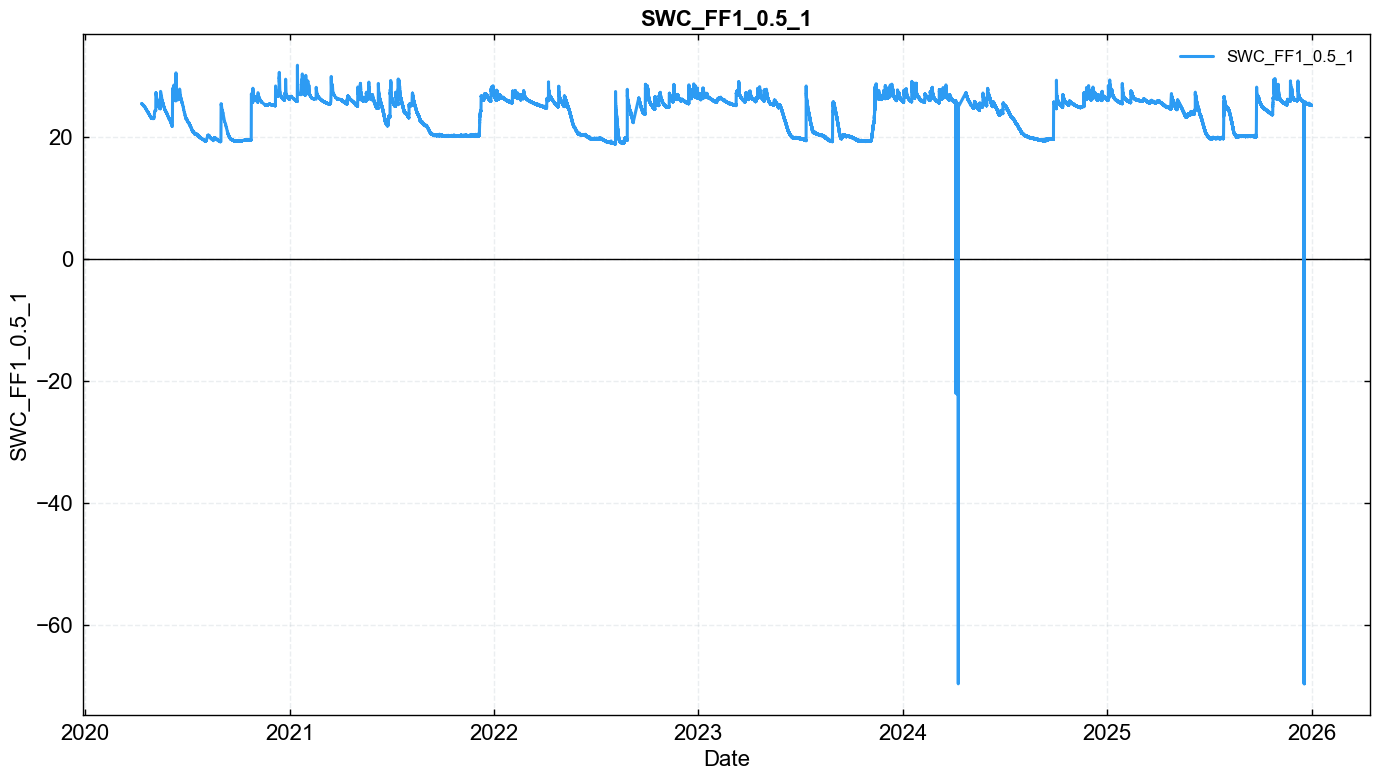

In [12]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## 🔍 Cross-check against the rest of the soil profile
Soil water content has no external reference — no weather service measures the soil at this plot. What it does have is **four other sensors in the same profile**, 5 to 50 cm below the same square metre of forest floor, plus the site's own **precipitation** record. Together those answer the question a single soil sensor cannot answer about itself: *is it still measuring the soil?*

The two failure modes worth separating:

- **it stops reporting** — communication failures, power loss. Loud and easy: gaps and impossible values, which the screening tests below remove.
- **it stops being coupled to the soil** — the soil shrinks away from the prongs in a dry summer, a root grows into the measurement volume, the backfill settles. This one is **quiet**: the series stays inside the physical range, stays smooth, and drifts plausibly. No statistical outlier test can see it. What gives it away is that the sensor no longer *responds*: rain falls, every deeper sensor wets up, and this one does not move.

> **What this can and cannot tell you — and what it means at 50 cm.** The depths are not replicates: a 5 cm sensor dries faster, wets first, and swings harder than a 50 cm sensor, so the levels differ and the correlations are far from 1. For the **deepest** probe the usual reasoning **reverses**. A shallow sensor sitting still while the layers underneath it wet up is a fault (water reaches 20 cm by passing through 5 cm first); a *deep* sensor sitting still while a summer storm wets the shallow layers above it is **physics** — the water simply never reaches 50 cm. So at this depth a collapsed rolling correlation and a rain-response ratio near zero are **expected every summer** and must not be read as faults. What *would* be suspicious is the opposite: 0.5 m failing to move when the whole profile above it wets up in winter/spring, or responding *before* the shallower sensors. Use the section to *find candidate periods*, then confirm each against the fieldbook and the depth ordering before putting anything in `REMOVE_DATES`.

*Sources: the FF1 soil profile (this site) and the screened precipitation product of notebook `30_PRODUCTS/08`.*

In [13]:
def to_30min_mean(series: pd.Series, min_coverage: float = 0.5,
                  max_step: pd.Timedelta = pd.Timedelta('10min')) -> pd.Series:
    """Resample a high-res series to 30MIN means on the end-labelled grid.

    Uses the same end-labelled convention as the database: the period ending at T
    holds the records in (T-30min, T].

    A plain record count cannot decide whether a half hour is well covered here,
    because the raw spacing changes over the record (10MIN before the 2021 logger
    rebuild, 1MIN after) - three records mean full coverage in the first era and
    a 90% gap in the second. Each record is therefore credited with the time it
    represents, i.e. the distance back to the previous record, capped at
    *max_step* so the first record after a long gap cannot claim the whole gap.
    A half hour is returned only when the records present cover at least
    *min_coverage* of it, otherwise NaN - so a gap never masquerades as data.
    """
    if series.empty:
        raise ValueError('to_30min_mean got an empty series')
    spacing = series.index.to_series().diff()
    step = spacing.median()
    if pd.isna(step) or step > pd.Timedelta('30min'):
        raise ValueError(f'cannot resample to 30MIN from a {step} series')
    represented = spacing.clip(upper=max_step).fillna(step)
    grouper = pd.Grouper(freq='30min', label='right', closed='right')
    means = series.groupby(grouper).mean()
    coverage = represented.groupby(grouper).sum() / pd.Timedelta('30min')
    return means.where(coverage >= min_coverage)


def report_blocks(index, label: str, maxgap: str = '1D', note=None):
    """Group a DatetimeIndex of hits into contiguous blocks and print them
    ready to paste into REMOVE_DATES."""
    if len(index) == 0:
        print(f'{label}: none')
        return
    hits = pd.Series(index=pd.DatetimeIndex(index), data=1).sort_index()
    grp = (hits.index.to_series().diff() > pd.Timedelta(maxgap)).cumsum()
    print(f'{label}: {grp.nunique()} period(s)')
    for _, blk in hits.groupby(grp):
        comment = '' if note is None else f'  # {note(blk.index)}'
        print(f"    ['{blk.index[0]:%Y-%m-%d %H:%M:%S}', '{blk.index[-1]:%Y-%m-%d %H:%M:%S}'],{comment}")

#### Negative control
`to_30min_mean` would happily return a series of NaN if handed something that is not high-resolution — silently producing an "empty" comparison that looks like a data gap. Prove it raises instead.

In [14]:
for _bad, _why in [(pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'empty series'),
                   (pd.Series([1.0, 2.0, 3.0],
                              index=pd.date_range('2020-01-01', periods=3, freq='1h')),
                    'already coarser than 30MIN')]:
    try:
        to_30min_mean(_bad)
    except ValueError as e:
        print(f'PASSED - {_why} raises: {e}')
    else:
        raise AssertionError(f'(!) FAILED - to_30min_mean accepted {_why}')

PASSED - empty series raises: to_30min_mean got an empty series
PASSED - already coarser than 30MIN raises: cannot resample to 30MIN from a 0 days 01:00:00 series


### Read the companion depths from the profile file
The other four depths, over the same period, are read from the **shared raw profile file** `SWC_FF1_PROFILE_RAW_2020-2025.parquet`, written once by [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb). They are reduced to 30MIN means immediately and the high-resolution frame is dropped again — the cross-check needs half-hourly means, not four more million-record frames in memory.

**Why a file and not another download.** The cross-check reference is the *same* five raw series in every depth's notebook, so downloading the companions separately in each one pulled identical data from the database five times over — and it was the slowest cell in every notebook. Downloading them once into a file and reading it here removes that repetition entirely.

**The screened variable is still downloaded from the database**, in the *Download* section above, and only that download feeds `StepwiseMeteoScreeningDb`. Screening needs the database **tags** (units, gain, offset, sensor position, data version) that travel with `data_detailed`; the profile file holds values only, so taking the target from it would silently strip them.

The file is **raw and unscreened** — it is the download, not a screened product. That is why the 5 cm probe's decoupled window **2020-08-01 → 2020-10-24** is still present in it and still has to be masked out of the companion reference (`prof_ref`) below.


In [15]:
# The companion depths are read from the pre-downloaded profile file rather than pulled
# from the database again: they are the same five raw series in every depth's notebook,
# so downloading them once is enough. Produced by SWC_FF1_PROFILE_2020-2025.ipynb.
# The screened variable is NOT taken from here - it comes from the database download
# above, because screening needs the database tags this file does not carry.
_profile_raw = pd.read_parquet(PROFILE_PRODUCT)
assert _profile_raw.index.name == 'TIMESTAMP_END', (
    f'(!) {PROFILE_PRODUCT} is not indexed on TIMESTAMP_END')
_absent = [_v for _v in COMPANION_FIELDS if _v not in _profile_raw.columns]
assert not _absent, (
    f'(!) profile file lacks companion column(s) {_absent} - re-run SWC_FF1_PROFILE_2020-2025.ipynb')
# Trim to exactly the screened period ([START, STOP), STOP excluded) so the cross-check
# cannot silently use a wider record than the one being screened.
_profile_raw = _profile_raw.loc[(_profile_raw.index >= pd.Timestamp(START))
                                & (_profile_raw.index < pd.Timestamp(STOP))]
assert not _profile_raw.empty, (
    '(!) profile file holds no records inside [START, STOP) - is it stale?')
print(f'profile file: {_profile_raw.shape[0]} records, '
      f'{_profile_raw.index[0]} -> {_profile_raw.index[-1]}')

# Target first, then the companions ordered by depth: one 30MIN frame for the whole profile.
prof = pd.DataFrame({FIELD: to_30min_mean(data_detailed[FIELD][FIELD].dropna())})
for _v in COMPANION_FIELDS:
    _series = _profile_raw[_v].dropna()
    if _series.empty:
        print(f'(!) {_v} has no data in this period and is left out of the cross-check.')
        continue
    prof[_v] = to_30min_mean(_series)
prof = prof.sort_index()
COMPANIONS = [c for c in prof.columns if c != FIELD]

# The 5 cm probe lost contact with the soil 2020-08-01..2020-10-24 (documented in its own
# notebook). The cache holds the RAW, unscreened companions, so that decoupled stretch is
# still present in 0.05 here; left in, it depresses the companion mean's rain response and
# inflates this depth's ratio in that window. Mask it out of the reference used for the
# rain-response and rolling-agreement diagnostics below (the target column, 0.5, is untouched).
MASK_005 = ('SWC_FF1_0.05_1', '2020-08-01', '2020-10-24')
prof_ref = prof.copy()
if MASK_005[0] in prof_ref.columns:
    prof_ref.loc[MASK_005[1]:MASK_005[2], MASK_005[0]] = np.nan
    print(f'masked {MASK_005[0]} over {MASK_005[1]}..{MASK_005[2]} out of the companion reference')

del _profile_raw  # the high-res companion frame is not needed again

assert COMPANIONS, '(!) no companion depth available - the cross-check below cannot run'
print(f'profile frame: {prof.shape[0]} half-hours, {prof.index[0]} -> {prof.index[-1]}')
print(f'target: {FIELD} | companions: {COMPANIONS}')

profile file: 2509501 records, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
masked SWC_FF1_0.05_1 over 2020-08-01..2020-10-24 out of the companion reference
profile frame: 100387 half-hours, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
target: SWC_FF1_0.5_1 | companions: ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1']


### Level, coverage and correlation
First the plain description: how much data each sensor has, where it sits, and how strongly the depths move together. Correlations between depths are expected to be **high but not near-perfect** (r ≈ 0.7-0.9 on daily means) and to *decrease with depth separation* — the 5 cm and 50 cm sensors measure genuinely different things.

In [16]:
print('data coverage per year (fraction of 30MIN periods with a value):')
display(prof.notna().groupby(prof.index.year).mean().round(3))

print('\nlevel and spread over the whole period [% VWC]:')
display(prof.describe().round(2))

print('\ncorrelation of daily means:')
display(prof.resample('D').mean().corr().round(3))

data coverage per year (fraction of 30MIN periods with a value):


,SWC_FF1_0.5_1,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1
TIMESTAMP_END,,,,,
2020,1.000,1.000,1.000,1.000,1.000
2021,0.977,0.977,0.977,0.977,0.977
2022,0.972,0.972,0.972,0.972,0.972
2023,0.998,0.998,0.998,0.998,0.998
2024,0.953,0.948,0.950,0.951,0.272
2025,1.000,1.000,1.000,1.000,0.828
2026,1.000,1.000,1.000,1.000,1.000



level and spread over the whole period [% VWC]:


,SWC_FF1_0.5_1,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1
count,98624.00,98538.00,98583.00,98585.00,83666.00
mean,24.12,29.52,29.77,31.23,27.15
std,2.77,5.45,5.26,4.11,3.51
min,3.96,-16.90,18.20,20.37,19.91
25%,20.71,24.67,25.29,27.77,23.65
50%,25.35,30.64,31.11,32.83,28.48
75%,26.25,34.08,33.53,34.27,29.51
max,31.75,39.71,54.26,39.03,36.41



correlation of daily means:


,SWC_FF1_0.5_1,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1
SWC_FF1_0.5_1,1.000,0.847,0.849,0.879,0.853
SWC_FF1_0.05_1,0.847,1.000,0.897,0.893,0.716
SWC_FF1_0.1_1,0.849,0.897,1.000,0.928,0.754
SWC_FF1_0.2_1,0.879,0.893,0.928,1.000,0.891
SWC_FF1_0.3_1,0.853,0.716,0.754,0.891,1.000


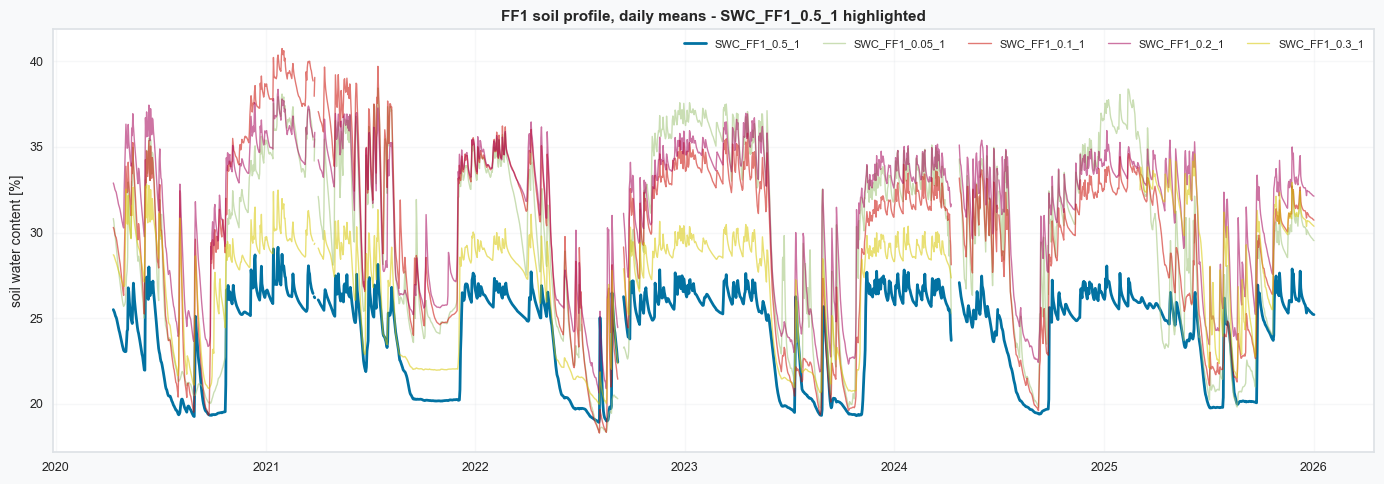

In [17]:
_daily = prof.resample('D').mean()
_daily_ref = prof_ref.resample('D').mean()  # companion mean with the 0.05 decoupled window masked
fig, ax = plt.subplots(figsize=(14, 5))
for _c in prof.columns:
    _lw, _alpha = (2.0, 1.0) if _c == FIELD else (1.0, .55)
    ax.plot(_daily.index, _daily[_c], label=_c, lw=_lw, alpha=_alpha)
ax.set_ylabel('soil water content [%]')
ax.set_title(f'FF1 soil profile, daily means - {FIELD} highlighted')
ax.legend(ncol=len(prof.columns), fontsize=8)
plt.tight_layout()
plt.show()

### Does the target still move with the profile?
Levels differ by depth, so compare **changes** rather than values: the daily change of the target against the daily change of the rest of the profile, correlated in a rolling 30-day window. For a shallow, well-coupled sensor this stays high (r ≈ 0.8-0.9).

**At 50 cm, read this diagnostic with care.** The deepest probe legitimately decouples from the profile every summer — the shallow sensors respond to a storm and this one correctly does not, because the water never arrives — so its rolling correlation collapses for months at a time as a matter of physics, not fault. On this record it sits near r ≈ 0.4 on the annual median (against ≈ 0.8 for the 5 cm probe), and dips below 0.3 across roughly 37 mostly-summer windows. That is expected. Judge decoupling by the **rain-response ordering** (next cell), never by this correlation alone. The companion mean here masks out the 5 cm sensor's own 2020 decoupling and is cross-checked against a fixed 0.1+0.2 m subset, so neither the 0.05 fault nor the 0.3 m dropout/replacement drives the number.

rolling 30-day r, full companion mean vs fixed 0.1+0.2 subset, median per year:


,full companions,fixed 0.1+0.2
TIMESTAMP_END,,
2020,0.49,0.39
2021,0.44,0.40
2022,0.56,0.52
2023,0.40,0.40
2024,0.38,0.41
2025,0.40,0.44
2026,0.85,0.86


rolling 30-day correlation of daily increments, target vs profile mean:


,count,mean,std,min,25%,50%,75%,max
TIMESTAMP_END,,,,,,,,
2020,246.0,0.49,0.27,-0.17,0.28,0.49,0.76,0.86
2021,365.0,0.44,0.30,-0.68,0.30,0.44,0.63,0.98
2022,365.0,0.48,0.33,-0.43,0.27,0.56,0.69,0.99
2023,365.0,0.36,0.36,-0.48,0.12,0.40,0.69,0.95
2024,343.0,0.42,0.27,-0.23,0.22,0.38,0.66,0.96
2025,365.0,0.39,0.32,-0.30,0.17,0.40,0.63,0.93
2026,1.0,0.85,NaN,0.85,0.85,0.85,0.85,0.85


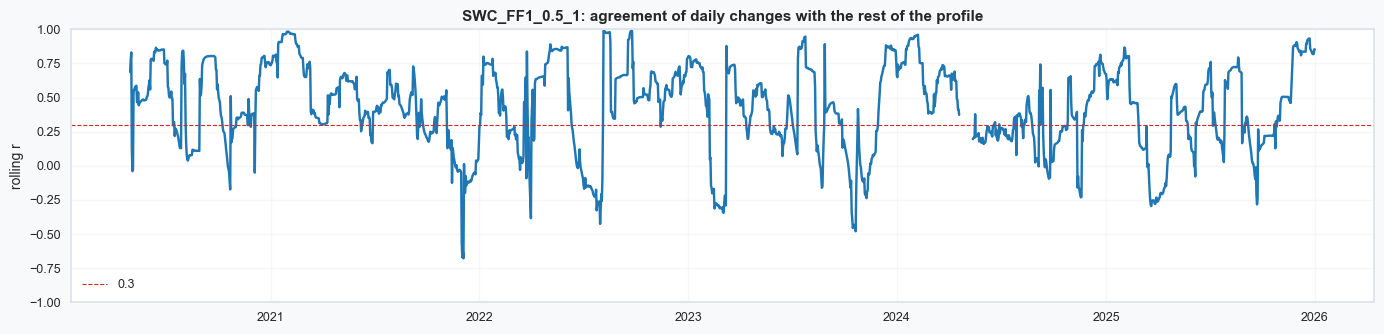

ROLLING AGREEMENT BELOW 0.3: 37 period(s)
    ['2020-05-03 00:00:00', '2020-05-05 00:00:00'],  # 3 day(s)
    ['2020-07-14 00:00:00', '2020-07-28 00:00:00'],  # 13 day(s)
    ['2020-08-06 00:00:00', '2020-08-29 00:00:00'],  # 24 day(s)
    ['2020-10-09 00:00:00', '2020-11-01 00:00:00'],  # 23 day(s)
    ['2020-11-22 00:00:00', '2020-11-22 00:00:00'],  # 1 day(s)
    ['2020-11-27 00:00:00', '2020-11-27 00:00:00'],  # 1 day(s)
    ['2020-12-04 00:00:00', '2020-12-04 00:00:00'],  # 1 day(s)
    ['2021-06-08 00:00:00', '2021-06-09 00:00:00'],  # 2 day(s)
    ['2021-06-24 00:00:00', '2021-06-28 00:00:00'],  # 5 day(s)
    ['2021-09-14 00:00:00', '2021-09-19 00:00:00'],  # 4 day(s)
    ['2021-09-25 00:00:00', '2021-10-13 00:00:00'],  # 19 day(s)
    ['2021-10-17 00:00:00', '2021-10-18 00:00:00'],  # 2 day(s)
    ['2021-11-06 00:00:00', '2022-01-02 00:00:00'],  # 58 day(s)
    ['2022-02-18 00:00:00', '2022-03-19 00:00:00'],  # 30 day(s)
    ['2022-03-24 00:00:00', '2022-04-01 00:00:00'],  # 7

In [18]:
_d_target = _daily[FIELD].diff()
_d_others = _daily_ref[COMPANIONS].mean(axis=1).diff()
rollcorr = _d_target.rolling(30, min_periods=20).corr(_d_others)

# The companion set is not constant: 0.3 m is dead 2024-04..2025-03 and was then replaced
# with a ~3% level shift, so a mean over 'whatever is present' changes membership mid-record.
# Confirm the picture does not hinge on that by repeating against a fixed 0.1+0.2 m subset.
_fixed = [c for c in COMPANIONS if c.endswith('_0.1_1') or c.endswith('_0.2_1')]
rollcorr_fixed = _d_target.rolling(30, min_periods=20).corr(_daily_ref[_fixed].mean(axis=1).diff())
print('rolling 30-day r, full companion mean vs fixed 0.1+0.2 subset, median per year:')
display(pd.DataFrame({'full companions': rollcorr.groupby(rollcorr.index.year).median(),
                      'fixed 0.1+0.2': rollcorr_fixed.groupby(rollcorr_fixed.index.year).median()}).round(2))

print('rolling 30-day correlation of daily increments, target vs profile mean:')
display(rollcorr.groupby(rollcorr.index.year).describe().round(2))

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(rollcorr.index, rollcorr, color='tab:blue')
ax.axhline(0.3, color='tab:red', lw=.8, ls='--', label='0.3')
ax.set_ylim(-1, 1)
ax.set_ylabel('rolling r')
ax.set_title(f'{FIELD}: agreement of daily changes with the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

report_blocks(rollcorr[rollcorr < 0.3].index, 'ROLLING AGREEMENT BELOW 0.3', maxgap='3D',
              note=lambda ix: f'{len(ix)} day(s)')

### Does the target still respond to rain?
The decisive test, but it must be read differently at each depth. For every day with more than 10 mm of precipitation, take the rise of each depth's daily mean over the following two days, and divide the target's rise by the profile mean's. A **shallow** sensor should give a ratio at or above 1 — water arrives at 5 cm first. The **deepest** sensor should give a ratio well **below** 1, and a ratio near **0** in summer is the *expected* result: a dry-season storm often wets the top layers and never reaches 50 cm. So a low ratio here is not damning on its own.

Read two things instead of the absolute ratio: the **ordering** of the depths (shallow wets first and most, deepest wets least or not at all — a deep sensor responding *before* the shallow ones would be the anomaly), and whether the deep sensor **does** wet up for the large **winter/spring** events, when water genuinely percolates the whole profile. The companion mean here has the 5 cm sensor's 2020 decoupling masked out, so it is not depressed in that window.

In [19]:
prec = pd.read_parquet(PREC_PRODUCT)[PREC_COL]
prec.index = prec.index + pd.Timedelta('15min')  # TIMESTAMP_MID -> TIMESTAMP_END, as used here
_shared = prof.index.intersection(prec.index)
assert len(_shared) > 0.5 * len(prof), (
    '(!) precipitation product does not line up with the profile - check the timestamp shift')
print(f'precipitation: {prec.index[0]} -> {prec.index[-1]}, '
      f'{len(_shared) / len(prof) * 100:.1f}% of the profile period covered')

_dprec = prec.reindex(prof.index).resample('D').sum(min_count=40)
_events = _dprec[_dprec > 10].index

_rows = []
for _day in _events:
    _before = _daily_ref.loc[:_day - pd.Timedelta('1D')].tail(1)
    _after = _daily_ref.loc[_day:_day + pd.Timedelta('2D')]
    if _before.empty or _after.empty:
        continue
    _resp = _after.max() - _before.iloc[0]
    _resp['PREC'] = _dprec.loc[_day]
    _rows.append(_resp.rename(_day))
resp = pd.DataFrame(_rows)
resp['RATIO'] = resp[FIELD] / resp[COMPANIONS].mean(axis=1)
print(f'\n{len(resp)} rain events > 10 mm/day in the screened period')

print('\nmedian rise per depth [% VWC] after a > 10 mm day, per year:')
display(resp.groupby(resp.index.year).median().round(2))

print('\nmedian response ratio (target / profile mean), all events and summer only:')
_summer = resp[resp.index.month.isin([7, 8, 9, 10])]
display(pd.DataFrame({'all events': resp['RATIO'].groupby(resp.index.year).median(),
                      'Jul-Oct': _summer['RATIO'].groupby(_summer.index.year).median(),
                      'n events': resp['RATIO'].groupby(resp.index.year).size()}).round(2))

precipitation: 2004-01-01 00:30:00 -> 2026-01-01 00:00:00, 100.0% of the profile period covered

198 rain events > 10 mm/day in the screened period

median rise per depth [% VWC] after a > 10 mm day, per year:


,SWC_FF1_0.5_1,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,PREC,RATIO
2020,0.69,1.69,2.95,2.11,2.06,14.4,0.45
2021,1.21,1.95,2.00,1.62,1.67,13.8,0.49
2022,1.43,1.17,1.57,1.45,1.32,13.9,0.82
2023,0.29,2.93,1.31,1.44,0.70,14.6,0.33
2024,0.59,2.32,1.73,1.92,0.94,15.5,0.32
2025,1.09,2.07,1.42,2.25,3.04,15.7,0.42



median response ratio (target / profile mean), all events and summer only:


,all events,Jul-Oct,n events
2020,0.45,0.13,20
2021,0.49,0.36,36
2022,0.82,0.79,30
2023,0.33,-0.01,32
2024,0.32,-0.02,39
2025,0.42,0.05,41


### Candidate periods for `REMOVE_DATES`
Four scans, each for a different failure mode. All of them produce **candidates only** — check each against the fieldbook and against the plots above before removing anything.

In [20]:
_target_hires = data_detailed[FIELD][FIELD].dropna()

report_blocks(_target_hires[(_target_hires < SWC_MIN) | (_target_hires > SWC_MAX)].index,
              f'OUTSIDE THE PHYSICAL RANGE [{SWC_MIN}, {SWC_MAX}] %', maxgap='1D',
              note=lambda ix: f'{len(ix)} record(s)')

_cov = prof[FIELD].notna().resample('D').mean()
report_blocks(_cov[_cov < 0.9].index, 'DAILY COVERAGE BELOW 90%', maxgap='2D',
              note=lambda ix: f'{len(ix)} day(s)')

report_blocks(rollcorr[rollcorr < 0.3].index, 'NOT MOVING WITH THE PROFILE (rolling r < 0.3)',
              maxgap='3D', note=lambda ix: f'{len(ix)} day(s)')

# A stuck sensor repeats one value. Runs are measured in *time*, not in records,
# because a record means ten minutes in the early era and one minute in the late one.
# Stored precision also changed: until the logger software update of 21 Apr 2020 the
# values arrived in steps of 0.1%, so during a slow dry-down they legitimately hold the
# same rounded value for hours. The threshold below is therefore loose, and the maxima
# printed with it are the more informative numbers.
_runs = (_target_hires != _target_hires.shift()).cumsum()
_spans = _target_hires.groupby(_runs).apply(lambda x: x.index[-1] - x.index[0])
_ends = _target_hires.groupby(_runs).apply(lambda x: x.index[-1])
_sizes = _target_hires.groupby(_runs).size()
_stuck = _spans[_spans >= pd.Timedelta('24h')]
print(f'IDENTICAL-VALUE RUNS LASTING >= 24 h: {len(_stuck)}')
for _g in _stuck.index:
    print(f"    ['{_ends.loc[_g] - _spans.loc[_g]:%Y-%m-%d %H:%M:%S}', "
          f"'{_ends.loc[_g]:%Y-%m-%d %H:%M:%S}'],  # {_sizes.loc[_g]} identical records")
for _label, _mask in [('whole record', _spans.notna()),
                      ('1MIN era only', _ends > pd.Timestamp('2021-03-27'))]:
    _sub = _spans[_mask]
    print(f'   longest identical-value run, {_label}: {_sub.max()} '
          f'(ending {_ends.loc[_sub.idxmax()]})')

print('\n(Copy any confirmed period into REMOVE_DATES below. Check the fieldbook first.)')

OUTSIDE THE PHYSICAL RANGE [0, 60] %: 3 period(s)
    ['2024-04-04 16:45:00', '2024-04-04 18:35:00'],  # 2 record(s)
    ['2024-04-07 06:28:00', '2024-04-09 14:33:00'],  # 12 record(s)
    ['2025-12-18 17:45:00', '2025-12-19 10:39:00'],  # 7 record(s)
DAILY COVERAGE BELOW 90%: 6 period(s)
    ['2021-03-24 00:00:00', '2021-04-02 00:00:00'],  # 10 day(s)
    ['2022-09-06 00:00:00', '2022-09-16 00:00:00'],  # 11 day(s)
    ['2023-06-15 00:00:00', '2023-06-15 00:00:00'],  # 1 day(s)
    ['2024-04-04 00:00:00', '2024-04-23 00:00:00'],  # 19 day(s)
    ['2024-06-29 00:00:00', '2024-07-01 00:00:00'],  # 3 day(s)
    ['2024-10-16 00:00:00', '2024-10-16 00:00:00'],  # 1 day(s)
NOT MOVING WITH THE PROFILE (rolling r < 0.3): 37 period(s)
    ['2020-05-03 00:00:00', '2020-05-05 00:00:00'],  # 3 day(s)
    ['2020-07-14 00:00:00', '2020-07-28 00:00:00'],  # 13 day(s)
    ['2020-08-06 00:00:00', '2020-08-29 00:00:00'],  # 24 day(s)
    ['2020-10-09 00:00:00', '2020-11-01 00:00:00'],  # 23 day(s)
    

### Adjudicate the candidates against the fieldbook
A candidate period means nothing until it is matched against what happened at the site. The GIN
fieldbook export is read here directly, so the adjudication written up below can be re-run and
challenged rather than taken on trust.

Filtering on the SWC device tags alone would miss most of it: the entries that explain these periods
are power-supply and logger entries carrying no soil device at all. The filter therefore also takes
anything at this profile's location, its logger/DAQ, or a free-text mention of soil, power, logger
or SDI-12.

In [21]:
import html
import re

_fb = pd.read_csv(FIELDBOOK, encoding='utf-8-sig')
_fb.columns = [c.strip() for c in _fb.columns]
_fb['date'] = pd.to_datetime(_fb['Date'], format='%d.%m.%Y', errors='coerce')
assert _fb['date'].notna().all(), '(!) unparsed dates in the fieldbook - check the date format'


def _plaintext(s):
    """GIN stores the entry body as HTML; strip the tags and entities."""
    return re.sub(r'\s+', ' ',
                  html.unescape(re.sub(r'<[^>]+>', ' ', str(s))).replace('\xa0', ' ')).strip()


_fb['text'] = _fb['Text'].map(_plaintext)
_mask = (_fb['Operation Tag'].astype(str).str.contains(r'SWC|iDL_FF1|iDAQ_FF1', case=False, na=False)
         | _fb['Location'].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb['text'].str.contains(r'soil|SWC|Teros|SDI|power|logger', case=False, na=False))
fb = (_fb[_mask & _fb['date'].between(START, STOP)]
      .drop_duplicates(subset=['date', 'Event Tag', 'Text'])
      .sort_values('date'))
assert len(fb) > 0, '(!) no fieldbook entries matched - has the export format changed?'
print(f'fieldbook: {len(_fb)} entries total, '
      f'{len(fb)} relevant to {PROFILE} within the screened period')


def fieldbook_near(start, stop=None, days: int = 3, maxchars: int = 220):
    """Print the fieldbook entries within *days* of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb['date'].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f'   (no fieldbook entry within +/-{days} days)')
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} {r['Event Tag']:<12s} {r['text'][:maxchars]}")

fieldbook: 2102 entries total, 129 relevant to FF1 within the screened period


In [22]:
# One entry per candidate period found by the scans above, REBUILT from THIS depth's scan
# output (not carried over from 5 cm). It is the record of what was adjudicated against the
# fieldbook. The out-of-range and coverage candidates are the discrete, physically meaningful
# ones; the 'not moving with the profile' scan fires in ~37 mostly-summer windows at this
# depth, which is deep-sensor physics rather than 37 site events - two representative windows
# are adjudicated here to show the fieldbook is silent, and the rest are not enumerated.
CANDIDATES = [
    ('2024-04-04', '2024-04-09', 'out-of-range values (negative failed reads)'),
    ('2025-12-18', '2025-12-19', 'out-of-range values (negative failed reads)'),
    ('2021-03-24', '2021-04-02', 'coverage gap'),
    ('2022-09-06', '2022-09-16', 'coverage gap'),
    ('2023-06-15', '2023-06-15', 'coverage gap'),
    ('2024-04-04', '2024-04-23', 'coverage gap (SDI-12 bus failure)'),
    ('2024-06-29', '2024-07-01', 'coverage gap'),
    ('2024-10-16', '2024-10-16', 'coverage gap'),
    ('2020-04-10', '2020-04-21', 'identical-value runs (0.1% precision steps)'),
    ('2022-06-12', '2022-08-05', 'rolling r < 0.3 (summer decoupling - expected at 50 cm)'),
    ('2023-09-28', '2023-11-28', 'rolling r < 0.3 (autumn decoupling - expected at 50 cm)'),
]
for _start, _stop, _why in CANDIDATES:
    print(f'\n--- {_start} -> {_stop}  ({_why})')
    fieldbook_near(_start, _stop, days=3)


--- 2024-04-04 -> 2024-04-09  (out-of-range values (negative failed reads))
   2024-04-02 HW_MOD       Worked on the deviceRepowered the sonic via ioLogik. This resolved the issue.

--- 2025-12-18 -> 2025-12-19  (out-of-range values (negative failed reads))
   2025-12-18 SW_MOD       Remotly uploaded new loggerprogram to the FF1 meteo logger
   2025-12-19 SW_MOD       Remotly updated a new loggerprogram to fix the windvane issue which existed for a long time. The last update didn't fix the issue as expected. https://gitlab.ethz.ch/gl/ch-lae_idl_ff1_0_1/-/tree/300b088aeddd5d3b3106c567b

--- 2021-03-24 -> 2021-04-02  (coverage gap)
   2021-03-24 HW_MOD       Installed new box with datalogger und multiplexer
   2021-03-24 TRASHED      Device trashed
   2021-03-24 HW_MOD       Shutdown the FF1 logger and all components for reconstruction of the logger box. We kept the naming of all variable where we didn't replaced the sensors by new sensor (type). Since we never added the location "box" 

#### How to read the candidate list

The outcome for `SWC_FF1_0.5_1`, read off the cell above and the scans. **Nothing here needs a manual removal** — every candidate is either caught by a physical rule, already missing, a known artefact, or expected deep-sensor physics.

- **Out of physical range** — 21 records, all of them isolated single-minute *negative* values (−13.4, −17.2, −21.5 … −69.6), never a run. They are failed SDI-12 reads: without NaN support the CR1000 firmware stores a failed read as that sensor's calibration polynomial evaluated at zero response, a fixed negative number (fieldbook 2020-04-10). All 21 fall inside two documented windows — the April 2024 SDI-12 bus failure (14 records) and the two remote logger-program uploads of 18-19 Dec 2025 (7). They are removed **without hand-adjudication**, and by two mechanisms rather than one: **9 of the 21 reach the absolute-limits test** (7 from April 2024, 2 from December 2025), while the other **12 are discarded earlier** with the stray 2/3/5/6-minute frequency groups that diive drops before screening (7 from April 2024, 5 from December 2025). This is the same split the 5 cm sensor shows (7 of 27 reaching the test), not a contrast with it. Note in particular that the December 2025 logger uploads generate stray frequency groups too — at every depth in this profile only 2 of those 7 records survive to the absolute-limits test — so the physical rule is not the sole mechanism there either. Either way the removal is physical and needs no adjudication. Removing them empties **no** half-hour — each is one isolated minute inside an otherwise populated half hour (the three April-2024 half-hours that end up below the 25% resampling threshold were already that sparse from the bus failure, not from this removal).

- **Coverage below 90%** — six periods, all of them documented profile-wide events, none specific to this sensor: the 2021-03 logger rebuild, the 2022-09 ten-day FF1 power-supply failure, the one-day FF1 power incident of 15 Jun 2023, the April-2024 SDI-12 bus failure (ended by unplugging the 0.3 m probe on 23 Apr), and the two station-wide outages 2024-06-29 → 07-01 (44 h, the *same* gap notebook `30_PRODUCTS/08` found in precipitation) and 2024-10-16 (8 h). Gaps need no removal — they are already missing.

- **Not moving with the profile** — the rolling-agreement scan fires across **37** windows, almost all of them May-October. This is **not** a list of faults: at 50 cm the correlation of daily increments with the shallower depths collapses every summer because a dry-season storm wets the top of the profile and never reaches this sensor. The rain-response table confirms it — the summer (Jul-Oct) ratio is near zero *every* year (0.13, 0.36, 0.79, −0.01, −0.02, 0.05 for 2020-2025) while the winter/spring ratio is ≈ 0.8, and the depth ordering is clean (mean response rank 2.17, 2.72, 2.83, 3.03, **3.78** from 5 cm to 50 cm — the deepest wets least, and it leads the shallower sensors in only 1 of 33 large events). Crucially, this sensor **does** wet up for every large winter/spring event (11 of 11 events > 20 mm in Nov-Apr give a positive rise, minimum +0.6% VWC), which is exactly the signature a decoupled deep probe would lack. **Kept, all of it** — removing a legitimate summer of non-response is the specific error this depth invites.

- **Identical-value runs** — two runs over 24 h, both in the **11 days between 2020-04-10 and 2020-04-21**, when values arrived in steps of exactly 0.1% (65 distinct values in 1637 records). That ends with the fieldbook entry of 2020-04-21, *"New datalogger software with two byte precision for the soil profile measurement"*: from that afternoon on the values carry full float precision (1945 distinct values in the next 2016 records) and the long runs stop. A storage-resolution artefact, not a stuck sensor — the values are usable, just coarse. In the 1MIN era no value ever repeats for more than **8 minutes**, and that one case sits inside the April 2024 bus trouble.

The verdict is an **empty `REMOVE_DATES`**. The failed reads go to absolute limits, the gaps are already gaps, and everything else is either a known artefact or the expected physics of the deepest probe in the profile. See the closing note *The record is clean* for the full positive case.

## ▶️ Start MeteoScreening with `diive`

> Validating data for variable SWC_FF1_0.5_1 ...

> Found 6 unique frequencies across 2505557 records.

> Found frequencies:

> The following frequencies will be used: [60.0, 600.0] (seconds)

> Note that there is more than one single time resolution and all data will be upsampled to match 
the highest found time resolution (60.0S).

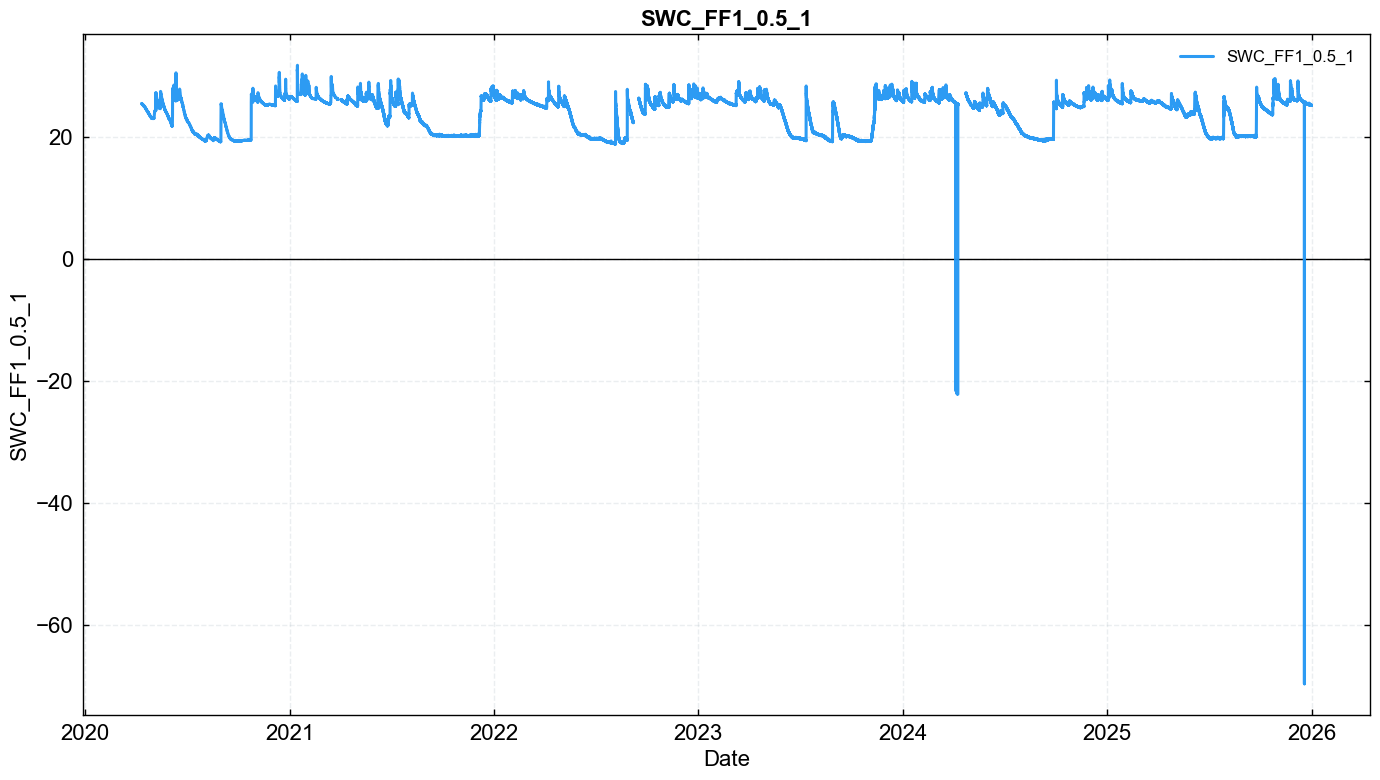

In [23]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Run a test → inspect its preview → commit with `mscr.addflag()`. Only the committed flag of the **most recent** test is added. Skip any test a variable does not need.

**What soil water content needs, and what it does not.** The series is smooth, strongly autocorrelated, and seasonally non-stationary: at 50 cm it ranges over roughly ten percentage points between a wet winter (~29%) and a dry August (~19%) — a narrower, more damped swing than the shallow sensors — and those wet and dry extremes are the most interesting values in it, not the least trustworthy. Two consequences run through this whole section:

- **Never split day and night.** Every test below is run with `separate_daytime_nighttime=False`. Soil moisture has no meaningful diurnal cycle at these depths, so a day/night split would only halve the sample of each threshold.
- **Distribution-wide tests do not belong here.** A z-score over the whole record measures how far a value sits from the multi-year mean, which for this variable is a statement about the season, not about data quality. Those tests are listed further down, switched off, with the reasoning.

What is actually needed here is shorter still than at 5 cm: the failed-read sentinels (**absolute limits**) and the **missing-values** flag — and, unlike the 5 cm sensor, **no manual removal**, because this depth carries no documented or evidenced fault. No spike test is committed — see *No spike test is used* below for the measurement that settles it.

In [24]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable SWC_FF1_0.5_1 ...

Plot the current cleaned data at any point during detection:

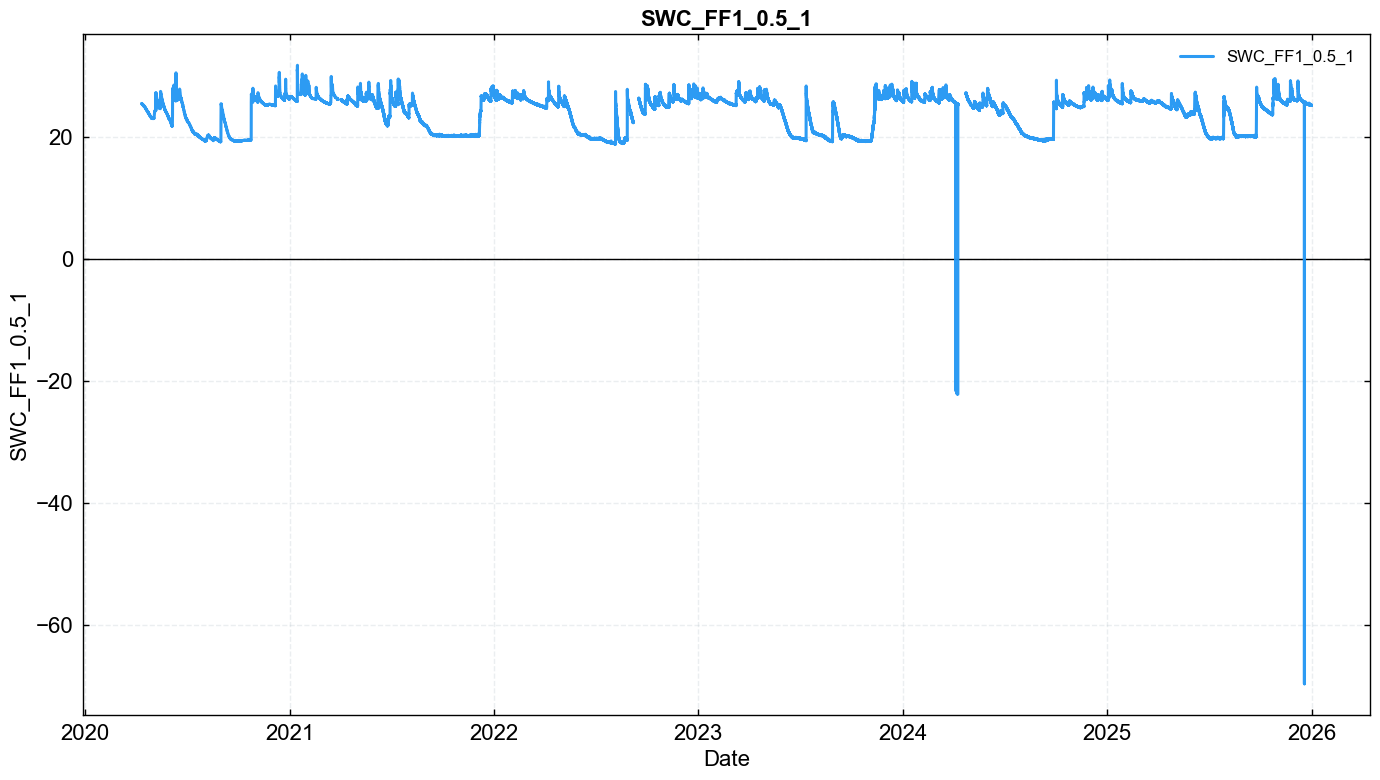

In [25]:
for key, val in mscr.outlier_detection.items():
    val.showplot_cleaned(interactive=False)

### Manual removal
Flag specific timestamps or time ranges for removal — known sensor failures, maintenance windows, etc. Give `[start, stop]` pairs and/or single timestamps.

In [26]:
if SHOW_PARAM_HELP:
    help(dv.outliers.ManualRemoval)

In [27]:
# No manual-removal windows for the 50 cm probe. This is the deepest sensor of the profile
# and, on the evidence above, its record is clean:
#   - every out-of-range value is a failed SDI-12 read, caught physically by absolute limits;
#   - every coverage gap is a documented profile-wide outage (already missing, nothing to remove);
#   - the only long flat runs are the 0.1%-precision fortnight of April 2020 (an artefact, usable);
#   - the rolling-agreement scan fires across ~37 summer windows, but that is the expected
#     physics of a deep sensor (a storm wets 5 cm and never reaches 50 cm), confirmed by the
#     rain-response ordering and by this sensor wetting up for every large winter/spring event.
# Manual removal is reserved for values that are WRONG BUT PLAUSIBLE - the one class no rule
# can catch - and this depth has none. See the closing note 'The record is clean'.
REMOVE_DATES = [
]
if REMOVE_DATES:
    mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)
else:
    print('No manual removal windows for this depth - skip the addflag cell below.')

No manual removal windows for this depth - skip the addflag cell below.


In [28]:
if REMOVE_DATES:
    mscr.addflag()

### Absolute limits
Flags values outside a fixed physical range `[minval, maxval]`. This is the workhorse test for soil water content: every artefact in this record that is *not* the 2020 decoupling is a failed sensor read, and every failed read lands far outside the physical range.

In [29]:
if SHOW_PARAM_HELP:
    help(dv.outliers.AbsoluteLimits)

> running AbsoluteLimits ...

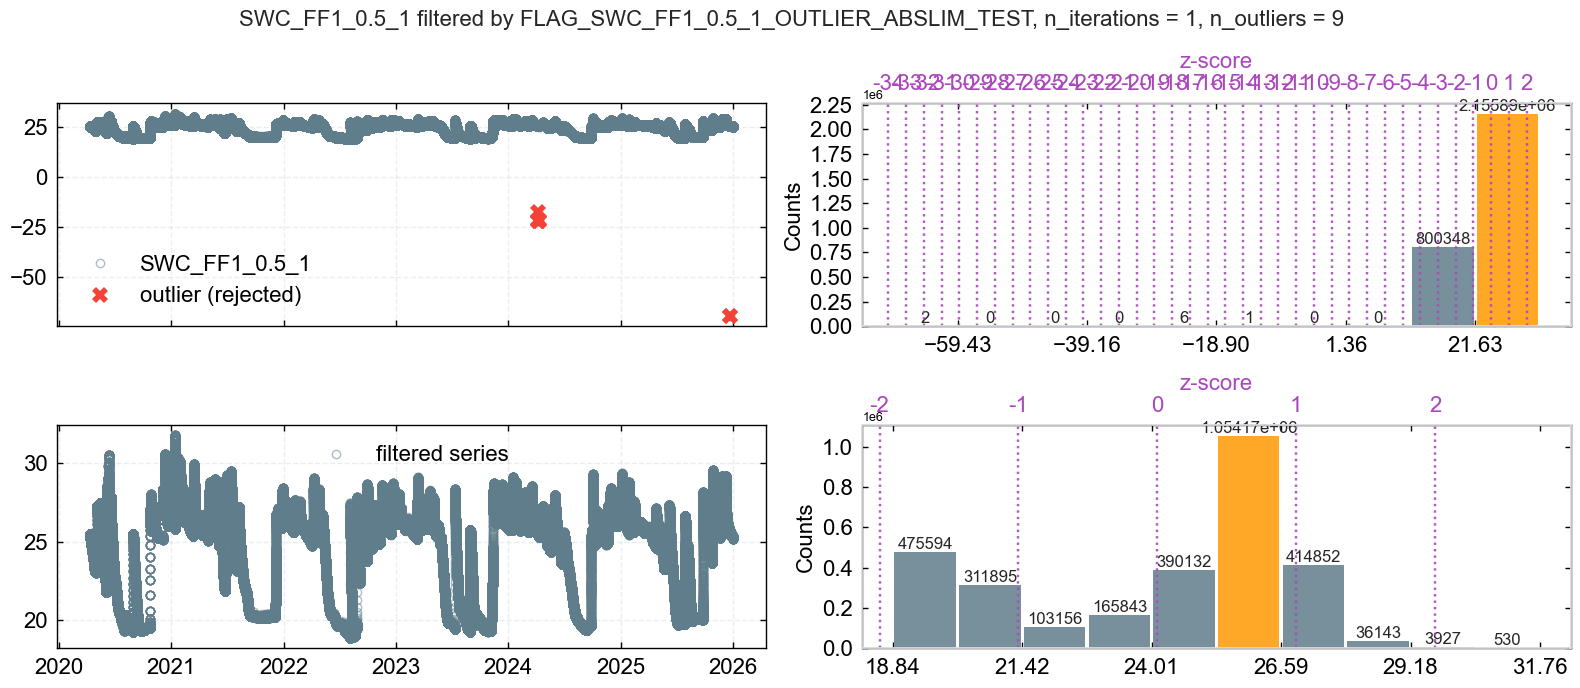

In [30]:
# Volumetric water content in %, so 0 is the hard physical floor. The upper limit is
# deliberately loose: the highest value ever recorded in this profile is 40.6%, well
# below any plausible porosity, so 60 can only fire on something unphysical.
# A failed SDI-12 read enters the record as that sensor's calibration polynomial
# evaluated at zero response, which lands at a fixed negative value per sensor
# (-14.4, -19.8, -69.6 ...) - hence a floor of 0 catches all of them and nothing else.
mscr.flag_outliers_abslim_test(minval=SWC_MIN, maxval=SWC_MAX, showplot=True, verbose=True)

In [31]:
mscr.addflag()

> ++Added flag column FLAG_SWC_FF1_0.5_1_OUTLIER_ABSLIM_TEST to flag data

### No spike test is used, and the Hampel filter still must not be committed
Every remaining template test (Hampel, z-score, rolling z-score, local SD, increments z-score, local outlier factor, trim low) is **left switched off**. This is the smoothest of the five profile sensors — the 99.99th percentile of minute-to-minute change in the 1MIN era is just **0.17% VWC** (against 0.31% at 5 cm) — so a spike filter looks harmless here. Measured on the record, run **after** absolute limits, it is not.

With the diive version pinned for this repo (which no longer lets the differenced filter degenerate in the back-filled era), the Hampel filter behaves, but it still removes real soil moisture. Flagged counts are reported **per era**, never as a total:

| Hampel call | flagged in the 10MIN era | flagged in the 1MIN era |
|---|---|---|
| `use_differencing=True, n_sigma=8` | 2 (0.00%) | 213 (0.01%) |
| `use_differencing=True, n_sigma=30` | 0 | 5 |
| `use_differencing=True, n_sigma=100` | 0 | 0 |
| `use_differencing=False, n_sigma=8` | 5 769 (1.15%) | 8 377 (0.34%) |

The differenced 10MIN count is **2**, not the 97 085 (19.4%) the *old* diive produced at 5 cm: the degeneracy is fixed, and `n_sigma` now does something (213 → 5 → 0). But the conclusion is the same as at every other depth, and now rests on the working filter: the differenced Hampel at `n_sigma=8` flags 215 records, and among them it removes a **real wetting front** — the summer storm of **5 Aug 2022**, one of the rare events that reached 50 cm (+6.1% VWC over the profile, ratio 3.0), whose arriving minutes (22:49 –22:51, +0.9/+2.3/+1.3% in successive minutes) it clips while keeping the tail. That is the single most physically real feature in a deep-sensor record, and any filter tight enough to fire removes it.

The others, for the record: **z-score over the whole record** measures distance from the multi-year mean, which for this variable *is* the season — a wet February and a dry August sit at opposite ends of a ~12-point range and both are correct. **Rolling z-score / local SD** fight the same physics. **Increments z-score** degenerates in the back-filled era exactly as the differenced Hampel used to. **Local outlier factor** is far too slow on 1MIN data. **Trim low** removes a fixed share of low values by construction — and the low values here (the August dry-down to ~19%) are the real signal.

So screening here is: **absolute limits** (physical range) + **missing values**, and nothing else. There is no manual removal at this depth and no spike test.

One practical warning for any test you do try: differencing-based tests compute their differences **after dropping missing records**, so the records flanking every gap are compared across the gap and look like spikes. This record has a 14-day gap in April 2024 and a 10-day one in September 2022.

If you want to try one anyway, the calls are below. Run it, look at the preview, check what it does to the 2020-2021 era and to the wetting fronts specifically, and only `mscr.addflag()` if it is genuinely removing artefacts.

In [32]:
# Optional, all off by default - read the note above before enabling any of these,
# and check the flagged count per era rather than the total.
# mscr.flag_outliers_hampel_test(window_length=60 * 24, n_sigma=8, use_differencing=False,
#                                separate_daytime_nighttime=False,
#                                repeat=False, showplot=True, verbose=3)
# mscr.flag_outliers_zscore_test(thres_zscore=4.5, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_zscore_rolling_test(thres_zscore=4.5, winsize=60 * 24 * 7,
#                                        repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_localsd_test(n_sd=7, winsize=60 * 24 * 7, constant_sd=False,
#                                 separate_daytime_nighttime=False,
#                                 repeat=False, showplot=True, verbose=True)
# mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)
# mscr.addflag()

### Missing values
Not an outlier test — flags missing records so they are counted in the overall `QCF`.

In [33]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_SWC_FF1_0.5_1_MISSING_TEST, newly 
calculated from variable SWC_FF1_0.5_1, with flag 0 (good values) where SWC_FF1_0.5_1 is available, 
flag 2 (bad values) where SWC_FF1_0.5_1 is missing.

### Overall quality flag QCF
Aggregate all committed test flags into one overall flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Required before corrections and resampling.

In [34]:
mscr.finalize_outlier_detection()

#### Reports

In [35]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: SWC_FF1_0.5_1

...

(count)      (count)                          
0/1/2

----------------------------------------------------------------------------------------------------
--------------------

1     SWC_FF1_0.5_1_MISSING                  0        2956249      0            100.00    0.00      
2956249/0/0

2     SWC_FF1_0.5_1_OUTLIER_ABSLIM           9        2956240      9            100.00    0.00      
2956240/0/9

====================================================================================================
====================

In [36]:
mscr.report_outlier_detection_qcf_flags()

════════════════════════════════════════════════════════════════════════════════════════════════════

INDIVIDUAL TEST FLAG STATISTICS: SWC_FF1_0.5_1

════════════════════════════════════════════════════════════════════════════════════════════════════

Total test flags: 2

┌─ REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

├─ SWC_FF1_0.5_1_OUTLIER_ABSLIM

│  Period          │ Pass (0)        │ Warn (1)        │ Fail (2)        │ Missing

│  -------------------------------------------------------------------------------------

│  OVERALL         │ 2956240 (100.0%) │     0 (  0.0%)  │     9 (  0.0%)  │    0 (  0.0%)

════════════════════════════════════════════════════════════════════════════════════════════════════

In [37]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: SWC_FF1_0.5_1

======================================================================

[1] TIME PERIOD

Start:  2020-04-10 14:50

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 2956240/2956249 (100.00%)

Data loss from QC:         9/2956249 (0.00%)

Final data coverage:       2956240/3011590 (98.16% of potential)

======================================================================

#### Plots

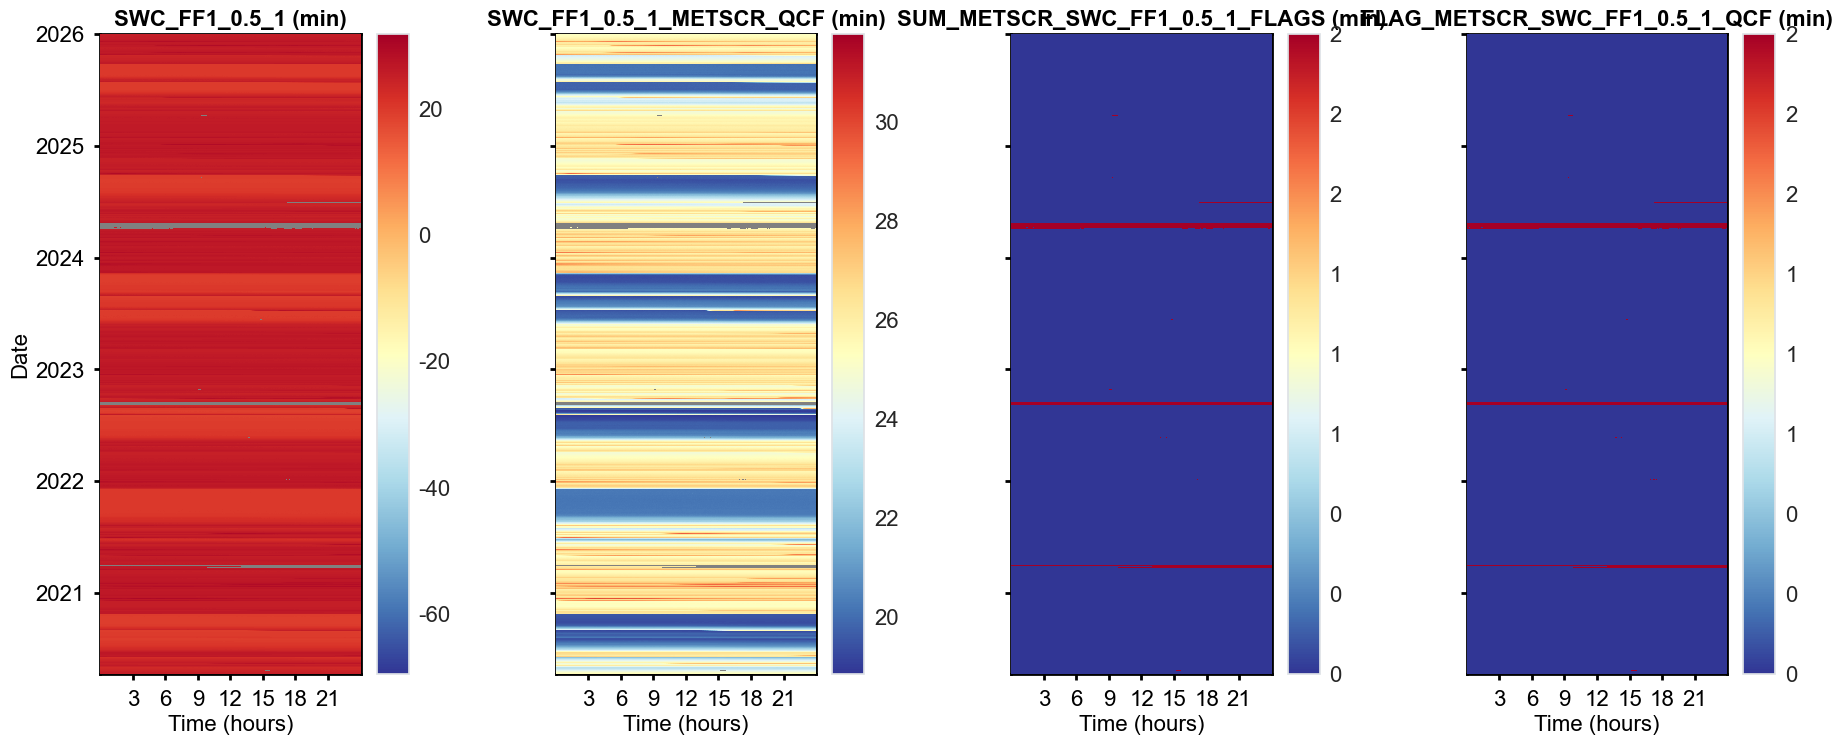

In [38]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. **None of them apply to soil water content**, and all calls below stay commented out.

The corrections diive offers are offset removals for radiation and relative humidity, threshold clipping, and setting ranges to a constant — every one of them writes a value the sensor did not measure. For this variable there is nothing to correct *within* the series: a probe reading too high or too low is a calibration matter (soil-specific permittivity calibration), which cannot be fixed after the fact from the series itself, and this deepest probe carries no fault to correct at all — the only edits are the failed-read minutes already removed by absolute limits.

> ⚠️ In particular, do **not** clip to a minimum: the failed reads are already gone via absolute limits, and clipping would replace a missing measurement with a fabricated 0% — which reads as "bone dry soil" downstream.

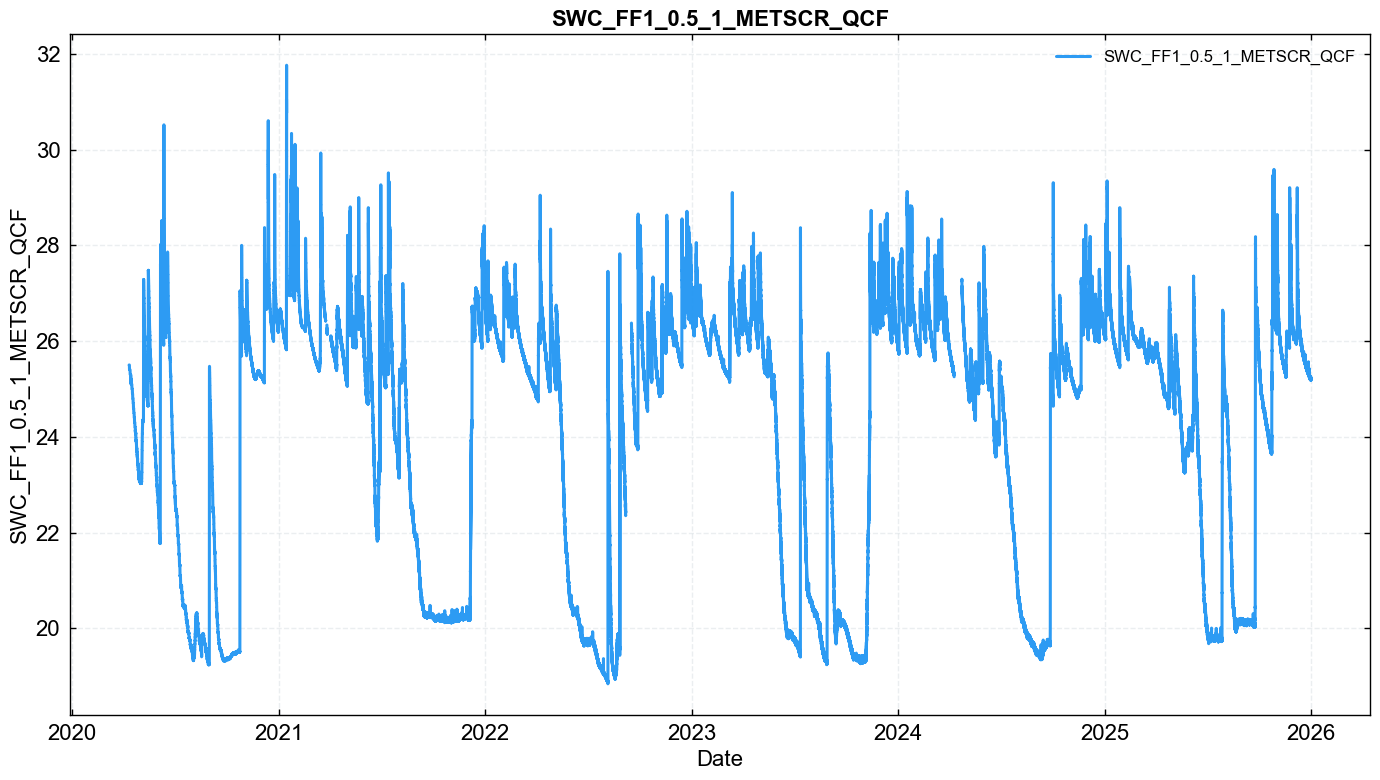

In [39]:
mscr.showplot_cleaned()

Inspect the most frequent values first (read-only, safe to run). For soil water content there should be **no** dominant repeated value: a value appearing thousands of times in the 1MIN era would mean a stuck sensor. Frequent repeats *are* expected in the 2020-2021 part, where each 10MIN reading was back-filled across ten 1MIN slots.

In [40]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count()} records) ---')
    print(vc.head(20))

--- SWC_FF1_0.5_1 (top 20 of 2956240 records) ---
SWC_FF1_0.5_1_METSCR_QCF
25.10000    2170
25.40000    1840
24.20000    1280
25.00000    1250
25.20000    1160
25.30000    1120
24.50000    1120
24.80000    1030
24.30000     920
24.70000     860
24.40000     860
25.50000     760
24.60000     750
24.90000     720
20.16612     312
20.17097     302
20.16185     301
20.16631     294
20.17795     290
20.17543     290
Name: count, dtype: int64


In [41]:
# All commented out on purpose - none of these apply to soil water content.
# mscr.correction_setto_max_threshold(threshold=60)
# mscr.correction_setto_min_threshold(threshold=0)
# mscr.correction_setto_value(dates=[['2022-04-01', '2022-04-05']], value=0, verbose=1)
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 🔁 Resampling

### Resample to 30MIN
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again (see *Timestamp convention*), ready for upload.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

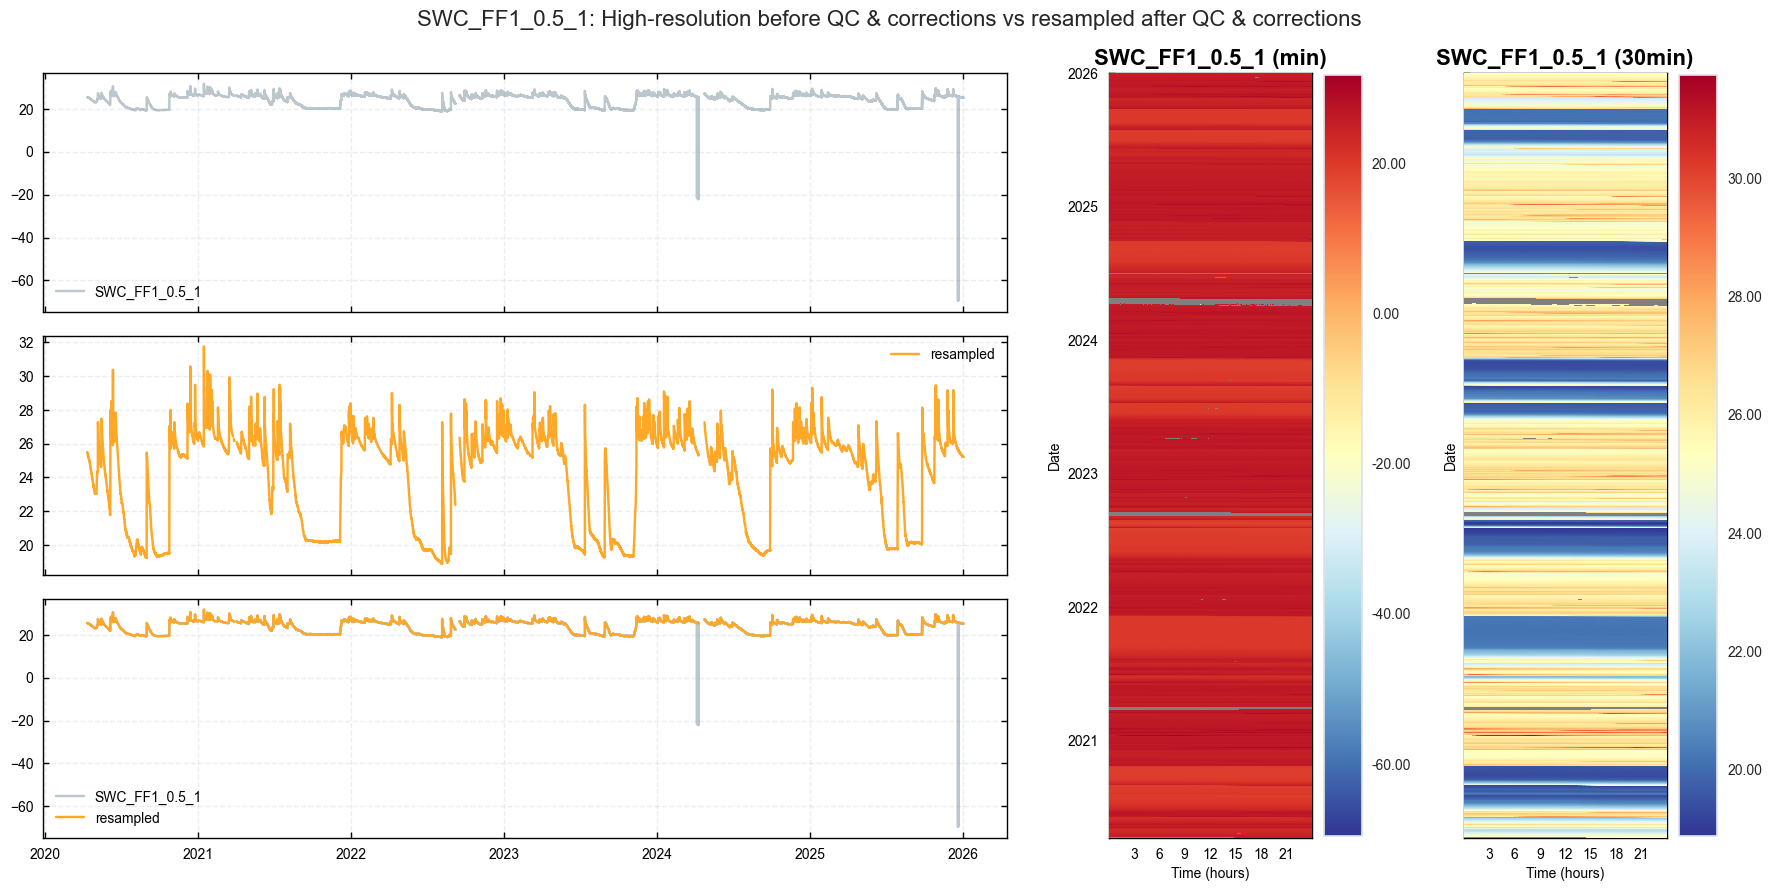

In [42]:
# mincounts_perc stays at the template default of .25, the opposite choice from the
# precipitation notebook. A 30MIN *mean* of a smooth state variable is well estimated
# from a quarter of the records, whereas a *sum* built from a quarter of the records
# under-reports by construction. Requiring near-complete coverage here would throw
# away good half-hours during the April 2024 bus trouble for no gain in accuracy.
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.25)
mscr.showplot_resampled()

### Check the resampled time resolution

In [43]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - SWC_FF1_0.5_1: 30min


### Re-check the screened product against the profile
The same comparison as before screening, now on the resampled 30MIN product. Screening should leave the agreement with the rest of the profile **no worse** than it was — if the correlation drops, a test removed real soil moisture rather than an artefact. At this depth almost nothing is removed (the 9 failed-read minutes that reach absolute limits; the other 12 never enter screening at all), so the agreement should be **essentially unchanged**; a drop would mean absolute limits somehow bit into real data. The companion mean used here has the 5 cm sensor's 2020 decoupling masked out, as above.

In [44]:
_screened = mscr.resampled_detailed[FIELD][FIELD]

_before = prof_ref.resample('D').mean()
_after = _before.copy()
_after[FIELD] = _screened.resample('D').mean()

r_before = _before[FIELD].diff().corr(_before[COMPANIONS].mean(axis=1).diff())
r_after = _after[FIELD].diff().corr(_after[COMPANIONS].mean(axis=1).diff())
n_before = prof[FIELD].notna().sum()
n_after = _screened.notna().sum()

print(f'{"":18s} {"n 30MIN":>9s} {"r(increments)":>15s} {"mean [%]":>10s}')
print(f'{"before screening":18s} {n_before:9d} {r_before:15.3f} {prof[FIELD].mean():10.2f}')
print(f'{"after screening":18s} {n_after:9d} {r_after:15.3f} {_screened.mean():10.2f}')
print(f'{"removed":18s} {n_before - n_after:9d} '
      f'({(1 - n_after / n_before) * 100:.2f}% of the half-hours that had a value)')

if r_after < r_before - 0.01:
    print('\n(!) WARNING - agreement with the profile got worse. A test may have removed real data.')
else:
    print('\nOK - screening did not degrade agreement with the rest of the profile.')

                     n 30MIN   r(increments)   mean [%]
before screening       98624           0.447      24.12
after screening        98588           0.446      24.12
removed                   36 (0.04% of the half-hours that had a value)

OK - screening did not degrade agreement with the rest of the profile.


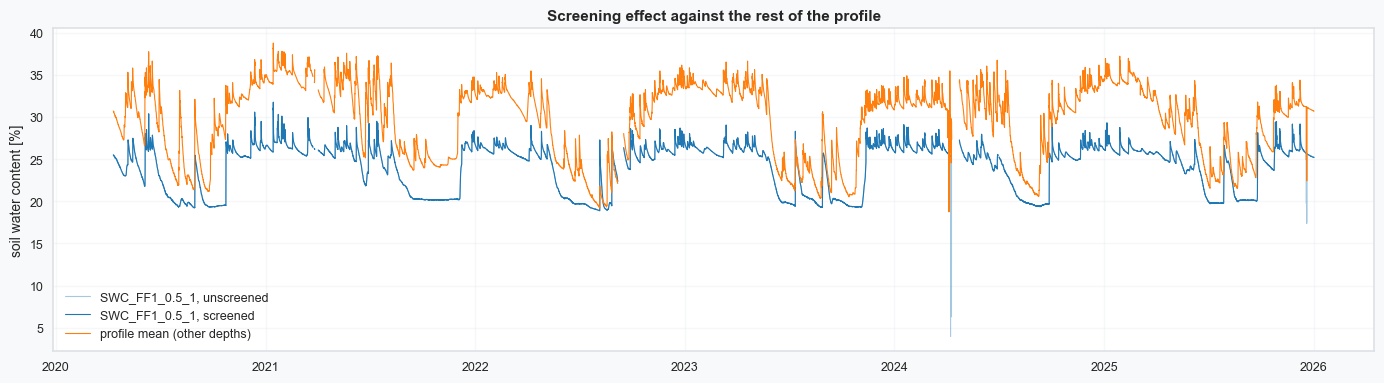

In [45]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prof.index, prof[FIELD], label=f'{FIELD}, unscreened', color='tab:blue', alpha=.4, lw=.8)
ax.plot(_screened.index, _screened, label=f'{FIELD}, screened', color='tab:blue', lw=.8)
ax.plot(prof.index, prof_ref[COMPANIONS].mean(axis=1), label='profile mean (other depths)',
        color='tab:orange', lw=.8)
ax.set_ylabel('soil water content [%]')
ax.set_title('Screening effect against the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

### 🧪 Screening invariants

The re-check above is a diagnostic: a number to look at. The two lines below are **invariants** — statements that must hold of the screened record, asserted rather than eyeballed, so a violation stops the notebook instead of sitting unnoticed in a printout. `REMOVE_DATES` is empty at this depth, so **absolute limits is the only value-removing test**, and these two asserts therefore cover everything screening took out: nothing counted as out-of-range was in fact inside the physical range, and nothing outside that range survived into the product.

The full two-direction audit — did every removal earn its place, and is every real feature still there? — lives in the `0.05` notebook, the only depth of the profile with a manual removal window and so the only one where a human judgement call needs policing, and in `0.2`. Here the re-check above plus these two asserts are enough. **If this depth ever gains a `REMOVE_DATES` window, port the full audit over**: the moment a removal rests on judgement rather than on a physical rule, one correlation and two asserts stop being able to defend it.


In [46]:
# Invariants, not diagnostics: the two things absolute limits must be true of, asserted rather
# than eyeballed. REMOVE_DATES is empty at this depth, so absolute limits is the only
# value-removing test and these two lines cover everything screening took out.
_raw_hires = data_detailed[FIELD][FIELD].dropna()
_oor = _raw_hires[(_raw_hires < SWC_MIN) | (_raw_hires > SWC_MAX)]
_surv = mscr.series_hires_cleaned[FIELD].dropna()

assert ((_oor < SWC_MIN) | (_oor > SWC_MAX)).all(), \
    '(!) a record counted as out-of-range is actually inside the physical range'
assert _surv.between(SWC_MIN, SWC_MAX).all(), '(!) an out-of-range value survived screening'

print(f'out-of-range records in the raw series: {len(_oor)}'
      + (f'  ({_oor.min():.2f} .. {_oor.max():.2f} % VWC)' if len(_oor) else ''))
print(f'surviving hi-res values, all inside [{SWC_MIN}, {SWC_MAX}]: '
      f'{_surv.min():.2f} .. {_surv.max():.2f} % VWC  -> PASSED')

out-of-range records in the raw series: 21  (-69.56 .. -13.40 % VWC)
surviving hi-res values, all inside [0, 60]: 18.84 .. 31.76 % VWC  -> PASSED


## ⬆️ Upload data to database

**Re-uploading overwrites the same variant — safe to re-run.** With `delete_from_db_before_upload=True` (below), the upload first *deletes*, then writes. The delete is scoped to the exact match `_measurement` + `varname` + `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its previous screened result. It never touches the raw data (different `data_version`, and a different `_raw` bucket), other variables, or other data versions. The delete-first step (rather than a plain overwrite) matters because InfluxDB keys a point by its full tag set: if a tag changed between runs (e.g. `units`, `gain`, `offset`), a plain write would leave the old point as a **duplicate** — the delete removes it regardless of tags.

Only the target variable is uploaded. The companion depths are only *read*, from the shared raw profile file, for the cross-check — each of them has its own notebook.

In [47]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['SWC_FF1_0.5_1'] between 2020-04-10T15:00:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['SWC'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['SWC_FF1_0.5_1']

v Upload finished.

### Verify upload
Download the just-uploaded data back and confirm the time resolution and timestamps. The offset is the same `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the timestamps below should again be local `TIMESTAMP_END` — matching what you screened.

In [48]:
# Fresh variable names so the screened originals (data_detailed etc.) are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.5_1'] from measurements ['SWC'],
data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

,SWC_FF1_0.5_1
TIMESTAMP_END,
2020-04-10 15:00:00,25.500000
2020-04-10 15:30:00,25.500000
2020-04-10 16:00:00,25.500000
2020-04-10 16:30:00,25.500000
2020-04-10 17:00:00,25.500000
...,...
2025-12-31 22:00:00,25.212793
2025-12-31 22:30:00,25.209556
2025-12-31 23:00:00,25.209057


In [49]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - SWC_FF1_0.5_1: freq=30min, first=2020-04-10 15:00:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [50]:
_end = datetime.now()
print(f"Finished: {_end.strftime('%Y-%m-%d %H:%M:%S')}  "
      f"(runtime {str(_end - NOTEBOOK_START).split('.')[0]})")

Finished: 2026-07-22 15:58:21  (runtime 0:07:28)


***
### 📝 Notes for this variable
- **Mean, not sum.** `RESAMPLING_AGG = 'mean'` — soil water content is a state, not a flux.
- **Units are volumetric %,** stored with `gain = 100` on a raw `m^3/m^3` reading. The database unit tag says `%` for both eras; the magnitudes (19-32) agree with that, and the export is checked against it above.
- **This is the deepest probe.** Its whole-period spread is the narrowest of the five (sd 2.77% VWC against 5.45 at 5 cm; range ≈ 19-32%), which is exactly how a 50 cm sensor should look — muted by design, the seasonal swing damped and delayed relative to the shallow layers.
- **Sensor history.** The FF1 profile is five **TEROS 12** probes installed on 19 Mar 2020 (the old EC-20 sensors were removed and trashed the same day) and first logged on 10 Apr 2020, which is where this record begins. The logger box was rebuilt on 24-26 Mar 2021, changing the resolution from 10MIN to 1MIN but not the sensors. **Nothing before 2020-04-10 belongs to this series, and at this depth there is nothing there at all.** Unlike the four shallower depths, `SWC_FF1_0.5_1` has **no** `meteoscreening_mst` record: the old profile had only four depths, which fits the fieldbook note that the old 50 cm probe "is broken for such a long time that we didn't even add it to the GIN database". At the other depths the FF1 *names* do carry a 2004-2019 mst record (207,597 to 260,312 30MIN records, each ending as that old probe died) — the old EC-20 (*M5*) profile **stored under the FF1 names** by the MeteoScreeningTool, not an earlier stretch of the TEROS sensors, as 0.2 m proves: there the mst series and raw `SWC_M5_0.2_1` have the same mean (21.8320) and r = 0.998. The raw `SWC_M5_*` names exist only in `ch-lae_raw`, and only over 2020-01-01 → 2020-04-10. Screening the two eras together would be a splice of two instruments, so this notebook screens the TEROS era only; where both exist they are joined in `30_PRODUCTS/09_METEO_SWC_FF1_2004-2025.ipynb`, behind a `FLAG_..._SOURCE` flag and with a `_HOMOGENIZED` column.
- **This probe was *not* replaced.** Unlike the 0.3 m sensor (dead Apr 2024-Mar 2025, then replaced with a ~3% level step), the 50 cm probe ran continuously for the whole 2020-2025 record with no sensor change and no level step — the annual mean holds at 23.2-24.7% and the seasonal envelope (Aug minimum ≈ 19-22%, Feb maximum ≈ 26-29%) repeats across all six years.
- **Two raw time resolutions** (10MIN then 1MIN) — see the dedicated section above.
- **The first 11 days are coarse.** From 2020-04-10 to 2020-04-21 values arrive in steps of 0.1% VWC; a logger software change on 21 Apr 2020 moved them to full float precision. Usable throughout, but expect the flat-run scan to fire there.
- **A failed sensor read is a number, not a gap.** The CR1000 firmware predates SDI-12 NaN support, so a failed read lands as a fixed negative value (this sensor: −13.4, −17.2, −21.5…−22.1, −69.6). Absolute limits, not the missing-values flag, is the test that catches them, which is why a floor of `0` is not optional. Of the 21 such records here, **9 reach that test** and the other 12 are discarded earlier with the stray frequency groups of April 2024 and December 2025 — the same two-mechanism split as at 5 cm (7 of 27), not a contrast with it. The committed run confirms the number: its QCF report rejects 9 of 2,956,249 measured records. None survives into the product either way.
- **The profile is the reference, and it is not a replicate set.** The depths differ in level and amplitude by design; only the *ordering* of the response is physically enforced (shallow wets first, deepest last). Nothing from the companion depths is written into this series.
- **Not a gap-filling source.** The companion depths and the precipitation product are used for comparison only.

***
### ✅ The record is clean: the positive case for `SWC_FF1_0.5_1`

There is no fault to remove at this depth. `REMOVE_DATES` is empty, and that is the correct outcome — not an omission. The case, from the cross-check above:

1. **In range.** Every one of the 21 out-of-range values is a single-minute negative failed read inside the two documented windows (April 2024 SDI-12 bus failure, Dec 2025 logger uploads). None survives into the product: 9 are removed by the absolute-limits test and the other 12 are discarded with the stray frequency groups before screening starts. No half-hour is emptied either way.
2. **Complete.** The only coverage gaps are the six documented profile-wide outages; there is no sensor-specific dropout, and no sensor replacement (contrast 0.3 m).
3. **No level step.** Annual means hold at 23.2-24.7% across 2020-2025 and the seasonal envelope repeats; the correlation of daily means with the other depths is 0.85-0.88.
4. **Still coupled to the soil, in the way a deep sensor should be.** It responds to rain *less* than the shallow layers — mean response rank 3.78 of 5, the deepest — and in summer often not at all (Jul-Oct ratio 0.13/0.36/0.79/−0.01/−0.02/0.05 for 2020-2025). That looks alarming through the 5 cm lens and is entirely normal here: a dry-season storm wets the top of the profile and never reaches 50 cm. The proof that the probe is still measuring the soil rather than an air gap is that it **does** wet up whenever water genuinely percolates the whole profile — a positive rise for **11 of 11** rain events over 20 mm in the Nov-Apr wet season (minimum +0.6% VWC), the autumn recovery of 23 Oct 2020 (+7.1% VWC, the *largest* rise of any depth that day), and the rare summer cloudbursts that do penetrate (5 Aug 2022, +6.1% VWC). A decoupled probe shows the opposite signature — the 5 cm sensor's 2020 fault was a total loss of response *including* the big autumn events — and nothing like it appears at 50 cm in any year.

**The trap this depth sets, avoided.** The rolling-agreement scan flags ~37 windows with r < 0.3, and the summer rain-response ratio sits near zero every year. Read in isolation, either would argue for deleting whole summers. Both are the expected physics of the deepest probe, and the depth ordering and the winter/spring response show the sensor is fine. No summer window is removed on the strength of a low correlation, because none of them carries the independent evidence — out-of-range values, coverage loss, a level step, a stuck run, or a fieldbook entry — that a real fault would.

### 🔎 Fieldbook cross-check (GIN export `CH-LAE-laegeren-export_20260719.csv`)

The export is read in the *Adjudicate the candidates* cell above; this is the summary. The 18 entries tagged to this depth's own location (`CH-LAE_FF1_0.5`, operation tag `CH-LAE_iSWC_FF1_0.5_1`) are all install/rebuild/power events shared by the whole profile — **none records a fault of the 50 cm probe itself**. Events that explain something in the data, none needing a removal beyond what the tests already do:

| Data feature | Fieldbook entry |
|---|---|
| 0.1% value steps, 2020-04-10 → 2020-04-21, and every identical-value run over 3 h | 2020-04-21, "New datalogger software with two byte precision for the soil profile measurement (Teros 12 and 21)" — after it, full float precision |
| Failed reads stored as fixed negative numbers rather than gaps | 2020-04-10, the CR1000 firmware predates SDI-12 NaN support and was deliberately not updated ("thinking of the imminent system upgrade") |
| Gap 2021-03-24 → 2021-03-29 (in pieces), and the 10MIN → 1MIN change | FF1 logger box rebuilt, all components shut down 24 Mar, new CR1000 and program, data acquisition restarted 26 Mar |
| Gap 2022-09-06 → 2022-09-16 (10 d) | FF1 12 V DC-DC power supply failed; "the data is missing for 10 days … due to power outage at the FF1", replaced 16 Sep |
| Gap 2023-06-15 (≈ 20 h) | "There is a problem with the power at ch-lae … the ff1 is [affected]. No system at ff1 was running for 'one day'"; "FF1 is running again" 16 Jun |
| 2024-04-04 → 2024-04-23: negative reads, stray 2/3/5/6-minute records, then 14 d out | the 0.3 m probe was failing and "caused an interruption of the SDI12 communication of all sensors at the same port"; unplugged 23 Apr 2024, which is exactly when this record resumes |
| Negative reads on all five depths, 18-19 Dec 2025 | two remote logger-program uploads to the FF1 meteo logger on exactly those days ("Remotly uploaded new loggerprogram") |

**Unexplained (station-wide, not soil-specific):** two coverage gaps have no fieldbook entry within ±3 days — **2024-06-29 → 2024-07-01** (44 h) and **2024-10-16** (8 h). The first is the *same* gap the precipitation notebook flagged, so it is a station-wide outage. Both are gaps, so both need no removal.

### 🧭 Reading a deep sensor (notes for the next depth copy)

This notebook is the 50 cm copy of the 5 cm pattern. Two things are worth carrying forward to any deep sensor, because they are the ways a clean deep record can be made to look faulty:

1. **The rolling-agreement and rain-response tests weaken with depth, and that is not a fault.** At 50 cm the rolling correlation collapses every summer and the rain-response ratio sits near zero for months, simply because water does not reach the sensor. Judge by the **ordering** of the depths (shallow wets first, deepest last) and by whether the sensor responds to the large **winter/spring** events, never by the absolute ratio or the correlation alone. Removing a summer of legitimate non-response is the specific mistake this depth invites.
2. **The companion set is not fixed, so mask and cross-check it.** The 5 cm sensor is decoupled 2020-08-01 → 2020-10-24 in the *raw*, unscreened profile file read here (`PROFILE_PRODUCT`) and is masked out of the companion reference; the 0.3 m sensor is dead Apr 2024 → Mar 2025 and returns with a ~3% level step. A companion mean over "whatever is present" therefore changes membership mid-record. The rolling-agreement cell cross-checks against a fixed 0.1+0.2 m subset to show the picture does not hinge on either.

If you add any outlier test, **report its flagged count per era, never as a total** — every depth has the same 10MIN-then-1MIN structure and the same differencing trap. This notebook commits no spike test, because after absolute limits there is nothing spiky left that is not a real wetting front.